# Results Dashboard (Deep Dive Archive)

Full diagnostics notebook for strikeout-prop performance, CLV, reliability,
error decomposition, and KPI scorecard generation. This is the deep-dive surface;
for daily operating reads use the focused notebooks:

- `production/notebooks/results_kpi_monitor.ipynb`
- `production/notebooks/results_calibration_lab.ipynb`
- `production/notebooks/results_gate_policy.ipynb`
- `production/notebooks/results_pnl_clv.ipynb`
- `production/notebooks/results_recommendation_audit.ipynb`
- `production/notebooks/results_bettable_cohort.ipynb`

This notebook reloads `artifacts/odds_log/ledger.parquet` fresh on each run.
Use it for verification and archival context, not as the only daily read.

> Decision policy and gate rules are canonical in
> `docs/reference/daily_kpi_protocol.md` and `production/ops/kpi_policy.json`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

%matplotlib inline

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "Python").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(f"Cannot find src/Python from cwd={Path.cwd()}")

sys.path.insert(0, str(ROOT / "src"))

from Python.market import DEFAULT_EDGE_FLOOR, bet_pnl, bootstrap_mean_ci
from Python.notebook_analysis_utils import (
    has_over_clv_red_flag,
    keep_best_available_lines,
    side_clv_roi_health,
)
from Python.odds_ledger import LEDGER_PATH, settled_bets

MIN_CLV_N = 100  # pre-registered skill-gate sample size (market_clv_gates.md)
EDGE_BIN_ORDER = ["<8% (no bet)", "8-12%", "12-16%", "16-20%", "20%+"]


def edge_bin_expr(col: str = "edge") -> pl.Expr:
    e = pl.col(col) * 100
    return (
        pl.when(e < 8).then(pl.lit("<8% (no bet)"))
        .when(e < 12).then(pl.lit("8-12%"))
        .when(e < 16).then(pl.lit("12-16%"))
        .when(e < 20).then(pl.lit("16-20%"))
        .otherwise(pl.lit("20%+"))
        .alias("edge_bin")
    )


def load_ledger() -> pl.DataFrame:
    if not LEDGER_PATH.exists():
        raise FileNotFoundError(f"No ledger at {LEDGER_PATH}. Run poll_odds.py --snapshot open first.")
    raw = pl.read_parquet(LEDGER_PATH)
    props = raw
    if "game_date" in props.columns:
        props = props.with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date"))
    return props


full = load_ledger()
staked_raw = full.filter((pl.col("status") == "settled") & (pl.col("stake") > 0)) if full.height else full
staked = keep_best_available_lines(staked_raw)
print(f"ledger={LEDGER_PATH}")
print(f"props={full.height}  settled_raw_n={staked_raw.height}  settled_best_line_n={staked.height}")

ledger=C:\Users\ckaplinger\Downloads\Personal-Projects\MLB-Props\artifacts\odds_log\ledger.parquet
props=802  settled_raw_n=298  settled_best_line_n=164


## 0. Ledger composition by model version

The `n_clv >= 150` gating rule (Section 16 / `floor_freeze_log.md`) is implicitly
written against a **stationary-while-accumulating** model. In practice the
ledger spans multiple production freezes — `k_rate_sha256` differs by `step10_180`
(07-28), `production`/Step 11 (184-feat), and the 2026-08-03 refreeze; the
Platt-regression probability calibration (`calibration_version`) was switched on
mid-stream. CLV aggregations that pool across these are averaging across
**different model versions**, and any per-n claim is qualified by which version
most of the n came from.

This section joins each settled ticket to `projections.parquet` (which the
logging path already annotates with `k_rate_sha256`, `tbf_sha256`,
`calibration_version`, `calibration_method` — see `production/projections/log_projections.py`
and `src/Python/live_assembly.py::score_frame`). It does **not** reopen anything;
it just surfaces which version each graded bet came from so you can qualify any
later-section headline ("CLV = +X.Xpp") by whether the bulk of the n lands on a
single freeze or spreads across three. If `k_rate_sha256` partitions the lead
version out cleanly, downstream significance tests should probably be re-read on
the lead-version subset instead of across freezes.

## Read Order

For daily decision-making, use `analysis/model_results/model_results_story.ipynb` first, then use this notebook for deep-dive verification.

### Operator Checklist (quick, repeatable)

1. **Is edge real yet?**
   - Section 11 (CLV reliability + CI)
   - Section 16/16b (BCa sweep + checkpoint)
2. **What is broken right now?**
   - Section 18 (stratified residual diagnostics)
   - Section 20 (model health scorecard)
3. **What action should we take today?**
   - Section 19 (chrono recalibration readiness)
   - `production/ops/kpi_daily_action.py`

### High-value reads after each settle update

- **Version-aware CLV concentration:** Section 0
- **By-side x matchup persistence:** Sections 5b and 18
- **Close-status distortion check:** Section 17 (artifact includes `close_status`)
- **Edge-band reliability drift:** Sections 11 and 12
- **Gate impact trend:** `artifacts/odds_log/gate_next_n_comparison.parquet`

Core operational flow is Sections 0-16. Appendix diagnostics are Sections 17-20.

In [2]:
# Section 0: ledger composition by model version + calibration version.
#
# The projection log is annotated with the SHAs/version strings at log time (see
# production/projections/log_projections.py -> _KEEP / _line_cols and src/Python/live_assembly.py
# -> score_frame report). We left-join the settled ledger onto it by
# (game_date, player_name) and report settled-bet n, PnL, win-rate, mean CLV,
# and the calibration_version tag per (k_rate_sha256, calibration_version).
#
# Each SHA is hashed with the leading 8 chars only for display legibility; the
# full hash is preserved for any audit lookup against projection_log.
#
# This cell writes the joined metadata to clv_version_map.parquet so later
# sections (5b, 11b) can reuse the `version_window` column without re-joining.

import hashlib  # noqa: F401  (kept for parity with other sections' import style)

# Section 0 depends on the projection log path; existing sections (5, 9) define
# this lazily inside their own cells. Since Section 0 runs first, define it here
# once and let later sections reuse if they want — they all re-define it anyway
# for safety, so this is forward-only.
PROJECTIONS_PATH = ROOT / "artifacts" / "projection_log" / "projections.parquet"

VERSION_MAP_PATH = LEDGER_PATH.parent / "clv_version_map.parquet"

# Re-read all rows of the projection log (don't reuse Section 5's `proj` subset).
_version_cols = [c for c in (
    "game_date",
    "player_name",
    "k_rate_sha256",
    "tbf_sha256",
    "calibration_version",
    "calibration_method",
    "calibration_scope",
    "p_over_3_5",
    "p_over_3_5_cal",
) if c in pl.scan_parquet(PROJECTIONS_PATH).collect_schema().names()]

_proj_meta = (
    pl.read_parquet(PROJECTIONS_PATH)
    .with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date"))
    .select(_version_cols)
    .unique(subset=["game_date", "player_name"], keep="first")
)

# settled_bets(full) -> status == "settled"; we include both staked (Kelly-passed)
# and un-staked rows so the composition view exposes bets Kelly declined to size,
# which is itself a selection/composition signal.
_settled_all = settled_bets(full)
if "game_date" not in _settled_all.columns:
    _settled_all = _settled_all  # sentinel; settled_bets always carries game_date
_vmap = _settled_all.join(_proj_meta, on=["game_date", "player_name"], how="left")

# Truncate SHAs for display; keep full hash in a separate column for audit lookup.
_vmap = _vmap.with_columns(
    pl.col("k_rate_sha256").cast(pl.Utf8).str.slice(0, 8).alias("k_rate_sha8"),
    pl.col("tbf_sha256").cast(pl.Utf8).str.slice(0, 8).alias("tbf_sha8"),
)
_vmap.write_parquet(VERSION_MAP_PATH)
print(f"wrote {VERSION_MAP_PATH.name}  ({_vmap.height} settled rows)")

# Compose the table that matters for any cross-section headline.
_sec0_src = _vmap.filter(pl.col("k_rate_sha256").is_not_null())
if _sec0_src.height:
    composition = (
        _sec0_src
        .group_by(["k_rate_sha8", "calibration_version"])
        .agg(
            pl.len().alias("n_settled"),
            (pl.col("stake") > 0).sum().alias("n_staked"),
            pl.col("pnl").sum().round(2).alias("pnl"),
            pl.col("result").eq("win").mean().round(3).alias("win_rate"),
            pl.col("clv_pp").mean().round(4).alias("mean_clv_pp"),
            pl.col("clv_pp").count().alias("n_clv"),
            pl.col("game_date").min().alias("first_game"),
            pl.col("game_date").max().alias("last_game"),
        )
        .sort(["first_game", "k_rate_sha8"])
    )
    print("\n--- settled bets by model + calibration version (showing k_rate SHA[0:8]) ---")
    with pl.Config(tbl_cols=-1, tbl_width_chars=220, fmt_str_lengths=14):
        print(composition)

    # Bankroll-weight: which version do most of the *graded CLV* bets come from?
    lead_version = (
        composition.filter(pl.col("n_clv") == composition["n_clv"].max())
        .row(0, named=True)
        if composition.height else None
    )
    if lead_version is not None:
        tot_clv = composition["n_clv"].sum()
        share = lead_version["n_clv"] / tot_clv if tot_clv else 0.0
        flag = "LOOK" if share < 0.6 else "ok"
        print(
            f"\nlead version: k_rate_sha8={lead_version['k_rate_sha8']}  "
            f"calibration_version={lead_version['calibration_version']}  "
            f"n_clv={lead_version['n_clv']}/{tot_clv} ({share:.0%})  -> {flag}"
            + (" (= CLV aggregation spans MULTIPLE freezes; treat pooled CLV as "
               "version-averaged before any significance claim.)"
               if flag == "LOOK" else " (CLV dominated by one freeze; pooled CLV "
               "is a reasonable single-version read.)")
        )

    # Bets missing the join (settled in ledger but no projection-row match).
    _missing = _vmap.filter(pl.col("k_rate_sha256").is_null()).height
    if _missing:
        print(f"\n  NOTE: {_missing} settled bets have NO matching projection log row "
              f"(missing `expected_K` / SHA on that game_date). These are silently "
              f"excluded from Section 5 (k_bias) and Section 9 (opponent tiers) — "
              f"n in those sections is smaller than the headline settled n.")
else:
    print("No settled bets with a matching projection-log row (has k_rate_sha256).")
    print("Either the ledger is empty here or the projection log has no rows for "
          "these game_dates yet.")

wrote clv_version_map.parquet  (792 settled rows)

--- settled bets by model + calibration version (showing k_rate SHA[0:8]) ---
shape: (2, 10)
┌─────────────┬─────────────────┬───────────┬──────────┬────────┬──────────┬─────────────┬───────┬────────────┬────────────┐
│ k_rate_sha8 ┆ calibration_ve… ┆ n_settled ┆ n_staked ┆ pnl    ┆ win_rate ┆ mean_clv_pp ┆ n_clv ┆ first_game ┆ last_game  │
│ ---         ┆ ---             ┆ ---       ┆ ---      ┆ ---    ┆ ---      ┆ ---         ┆ ---   ┆ ---        ┆ ---        │
│ str         ┆ str             ┆ u32       ┆ u32      ┆ f64    ┆ f64      ┆ f64         ┆ u32   ┆ str        ┆ str        │
╞═════════════╪═════════════════╪═══════════╪══════════╪════════╪══════════╪═════════════╪═══════╪════════════╪════════════╡
│ 5c8e1276    ┆ null            ┆ 131       ┆ 70       ┆ 271.38 ┆ 0.473    ┆ 0.0022      ┆ 117   ┆ 2026-07-30 ┆ 2026-08-02 │
│ db4d629a    ┆ prob_calibrati… ┆ 661       ┆ 228      ┆ 155.06 ┆ 0.558    ┆ 0.0015      ┆ 450   ┆ 2026-08

## 1. Overall Performance

In [3]:
def summarize(df: pl.DataFrame, label: str) -> dict:
    d = df.filter(pl.col("stake") > 0) if "stake" in df.columns else df
    n = d.height
    pnl = float(d["pnl"].sum()) if n and "pnl" in d.columns else 0.0
    staked_amt = float(d["stake"].sum()) if n and "stake" in d.columns else 0.0
    win_rate = float(d["result"].eq("win").mean()) if n and "result" in d.columns else float("nan")
    roi = (pnl / staked_amt * 100) if staked_amt else float("nan")
    clv_all = full.filter(pl.col("clv_pp").is_not_null())
    clvs = [float(x) for x in clv_all["clv_pp"].to_list()] if clv_all.height else []
    row = {"cohort": label, "n_bets": n, "pnl": round(pnl, 2), "staked": round(staked_amt, 2),
           "roi_pct": round(roi, 2), "win_rate": round(win_rate, 3), "n_clv": len(clvs)}
    if len(clvs) >= 5:
        m, lo, hi = bootstrap_mean_ci(clvs)
        row["mean_clv_pct"] = round(m * 100, 3)
        row["clv_ci_lo_pct"] = round(lo * 100, 3)
        row["clv_ci_hi_pct"] = round(hi * 100, 3)
        gate = "PASS" if lo > 0 and len(clvs) >= MIN_CLV_N else (
            "FAIL" if hi < 0 and len(clvs) >= MIN_CLV_N else "INCONCLUSIVE"
        )
        row["gate"] = gate
    return row

overall_row = summarize(staked, "overall (all-time)")
overall_df = pl.DataFrame([overall_row])
print(overall_df)
print(f"\nCLV skill gate: n_clv={overall_row['n_clv']} / {MIN_CLV_N} required "
      f"({min(100, overall_row['n_clv'] / MIN_CLV_N * 100):.0f}% of sample target)")

shape: (1, 11)
┌─────────────┬────────┬───────┬──────────┬───┬─────────────┬────────────┬────────────┬────────────┐
│ cohort      ┆ n_bets ┆ pnl   ┆ staked   ┆ … ┆ mean_clv_pc ┆ clv_ci_lo_ ┆ clv_ci_hi_ ┆ gate       │
│ ---         ┆ ---    ┆ ---   ┆ ---      ┆   ┆ t           ┆ pct        ┆ pct        ┆ ---        │
│ str         ┆ i64    ┆ f64   ┆ f64      ┆   ┆ ---         ┆ ---        ┆ ---        ┆ str        │
│             ┆        ┆       ┆          ┆   ┆ f64         ┆ f64        ┆ f64        ┆            │
╞═════════════╪════════╪═══════╪══════════╪═══╪═════════════╪════════════╪════════════╪════════════╡
│ overall     ┆ 164    ┆ 72.58 ┆ 12092.76 ┆ … ┆ 0.139       ┆ -0.189     ┆ 0.474      ┆ INCONCLUSI │
│ (all-time)  ┆        ┆       ┆          ┆   ┆             ┆            ┆            ┆ VE         │
└─────────────┴────────┴───────┴──────────┴───┴─────────────┴────────────┴────────────┴────────────┘

CLV skill gate: n_clv=575 / 100 required (100% of sample target)


## 2. Last 7 Days

In [4]:
if full.height and "game_date" in full.columns:
    from datetime import datetime, timedelta

    max_date = datetime.strptime(full["game_date"].max(), "%Y-%m-%d").date()
    cutoff = max_date - timedelta(days=6)
    last7 = staked.filter(
        pl.col("game_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False) >= cutoff
    )

    daily = (
        last7.group_by("game_date")
        .agg(
            pl.len().alias("n"),
            pl.col("pnl").sum().alias("pnl"),
            pl.col("stake").sum().alias("staked"),
            pl.col("result").eq("win").mean().alias("win_rate"),
        )
        .with_columns((pl.col("pnl") / pl.col("staked") * 100).round(2).alias("roi_pct"))
        .sort("game_date")
    )
    print(f"Last 7 days (since {cutoff}):")
    print(daily)
    last7_row = summarize(last7, "last_7_days")
    print()
    print(pl.DataFrame([last7_row]))
else:
    print("No ledger rows yet.")

Last 7 days (since 2026-08-11):
shape: (6, 6)
┌────────────┬─────┬─────────────┬────────────┬──────────┬─────────┐
│ game_date  ┆ n   ┆ pnl         ┆ staked     ┆ win_rate ┆ roi_pct │
│ ---        ┆ --- ┆ ---         ┆ ---        ┆ ---      ┆ ---     │
│ str        ┆ u32 ┆ f64         ┆ f64        ┆ f64      ┆ f64     │
╞════════════╪═════╪═════════════╪════════════╪══════════╪═════════╡
│ 2026-08-11 ┆ 12  ┆ 24.032165   ┆ 910.788494 ┆ 0.5      ┆ 2.64    │
│ 2026-08-12 ┆ 8   ┆ -195.126501 ┆ 447.257484 ┆ 0.25     ┆ -43.63  │
│ 2026-08-13 ┆ 4   ┆ -2.409109   ┆ 330.015628 ┆ 0.5      ┆ -0.73   │
│ 2026-08-14 ┆ 9   ┆ -60.732254  ┆ 505.326443 ┆ 0.555556 ┆ -12.02  │
│ 2026-08-15 ┆ 9   ┆ -392.421119 ┆ 733.007669 ┆ 0.222222 ┆ -53.54  │
│ 2026-08-17 ┆ 9   ┆ 64.096353   ┆ 610.631173 ┆ 0.555556 ┆ 10.5    │
└────────────┴─────┴─────────────┴────────────┴──────────┴─────────┘



shape: (1, 11)
┌─────────────┬────────┬─────────┬─────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ cohort      ┆ n_bets ┆ pnl     ┆ staked  ┆ … ┆ mean_clv_p ┆ clv_ci_lo_ ┆ clv_ci_hi_ ┆ gate       │
│ ---         ┆ ---    ┆ ---     ┆ ---     ┆   ┆ ct         ┆ pct        ┆ pct        ┆ ---        │
│ str         ┆ i64    ┆ f64     ┆ f64     ┆   ┆ ---        ┆ ---        ┆ ---        ┆ str        │
│             ┆        ┆         ┆         ┆   ┆ f64        ┆ f64        ┆ f64        ┆            │
╞═════════════╪════════╪═════════╪═════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ last_7_days ┆ 51     ┆ -562.56 ┆ 3537.03 ┆ … ┆ 0.139      ┆ -0.189     ┆ 0.474      ┆ INCONCLUSI │
│             ┆        ┆         ┆         ┆   ┆            ┆            ┆            ┆ VE         │
└─────────────┴────────┴─────────┴─────────┴───┴────────────┴────────────┴────────────┴────────────┘


## 3. Results vs. CLV

Same-day PnL and CLV can diverge — a day can win money on variance while the
market still moved against the closing side (negative CLV), or vice versa.
CLV is the more forward-looking signal since it doesn't depend on a single
game's K outcome.

In [5]:
clv_by_day = (
    full.filter(pl.col("clv_pp").is_not_null())
    .group_by("game_date")
    .agg(pl.col("clv_pp").mean().alias("mean_clv_pct") * 100, pl.len().alias("n_clv"))
    .sort("game_date")
)
pnl_by_day = (
    staked.group_by("game_date")
    .agg(pl.col("pnl").sum().alias("pnl"), pl.col("result").eq("win").mean().round(3).alias("win_rate"))
    .sort("game_date")
)
results_vs_clv = pnl_by_day.join(clv_by_day, on="game_date", how="full", coalesce=True).sort("game_date")
print("Results vs. CLV by day:")
print(results_vs_clv)

Results vs. CLV by day:
shape: (17, 5)
┌────────────┬─────────────┬──────────┬──────────────┬───────┐
│ game_date  ┆ pnl         ┆ win_rate ┆ mean_clv_pct ┆ n_clv │
│ ---        ┆ ---         ┆ ---      ┆ ---          ┆ ---   │
│ str        ┆ f64         ┆ f64      ┆ f64          ┆ u32   │
╞════════════╪═════════════╪══════════╪══════════════╪═══════╡
│ 2026-07-30 ┆ -266.393565 ┆ 0.444    ┆ -0.07505     ┆ 16    │
│ 2026-07-31 ┆ 282.668799  ┆ 0.538    ┆ 1.028367     ┆ 47    │
│ 2026-08-01 ┆ 184.763337  ┆ 0.667    ┆ -0.055837    ┆ 4     │
│ 2026-08-02 ┆ -160.879656 ┆ 0.4      ┆ -0.280077    ┆ 56    │
│ 2026-08-03 ┆ -148.637855 ┆ 0.5      ┆ 0.938228     ┆ 27    │
│ …          ┆ …           ┆ …        ┆ …            ┆ …     │
│ 2026-08-12 ┆ -195.126501 ┆ 0.25     ┆ -0.107256    ┆ 45    │
│ 2026-08-13 ┆ -2.409109   ┆ 0.5      ┆ 0.059353     ┆ 19    │
│ 2026-08-14 ┆ -60.732254  ┆ 0.556    ┆ null         ┆ null  │
│ 2026-08-15 ┆ -392.421119 ┆ 0.222    ┆ 0.311062     ┆ 44    │
│ 2026-08-17 ┆ 6

In [6]:
staked_binned = staked.with_columns(edge_bin_expr())
edge_bin_tbl = (
    staked_binned.group_by("edge_bin")
    .agg(
        pl.len().alias("n"),
        pl.col("pnl").sum().round(2).alias("pnl"),
        pl.col("stake").sum().round(2).alias("staked"),
        pl.col("result").eq("win").mean().round(3).alias("win_rate"),
        pl.col("clv_pp").mean().alias("mean_clv_pct"),
        pl.col("clv_pp").count().alias("n_clv"),
    )
    .with_columns(
        (pl.col("pnl") / pl.col("staked") * 100).round(2).alias("roi_pct"),
        (pl.col("mean_clv_pct") * 100).round(3),
    )
    .with_columns(pl.col("edge_bin").cast(pl.Enum(EDGE_BIN_ORDER)))
    .sort("edge_bin")
)
print("Edge-bin performance (staked bets only, best-edge book per prop):")
print(edge_bin_tbl)

Edge-bin performance (staked bets only, best-edge book per prop):
shape: (4, 8)
┌──────────┬─────┬─────────┬─────────┬──────────┬──────────────┬───────┬─────────┐
│ edge_bin ┆ n   ┆ pnl     ┆ staked  ┆ win_rate ┆ mean_clv_pct ┆ n_clv ┆ roi_pct │
│ ---      ┆ --- ┆ ---     ┆ ---     ┆ ---      ┆ ---          ┆ ---   ┆ ---     │
│ enum     ┆ u32 ┆ f64     ┆ f64     ┆ f64      ┆ f64          ┆ u32   ┆ f64     │
╞══════════╪═════╪═════════╪═════════╪══════════╪══════════════╪═══════╪═════════╡
│ 8-12%    ┆ 29  ┆ -294.56 ┆ 1227.99 ┆ 0.414    ┆ 0.916        ┆ 24    ┆ -23.99  │
│ 12-16%   ┆ 51  ┆ 95.94   ┆ 2843.81 ┆ 0.569    ┆ 0.626        ┆ 36    ┆ 3.37    │
│ 16-20%   ┆ 35  ┆ -929.1  ┆ 2486.23 ┆ 0.314    ┆ 0.745        ┆ 25    ┆ -37.37  │
│ 20%+     ┆ 49  ┆ 1200.31 ┆ 5534.73 ┆ 0.592    ┆ 0.753        ┆ 36    ┆ 21.69   │
└──────────┴─────┴─────────┴─────────┴──────────┴──────────────┴───────┴─────────┘


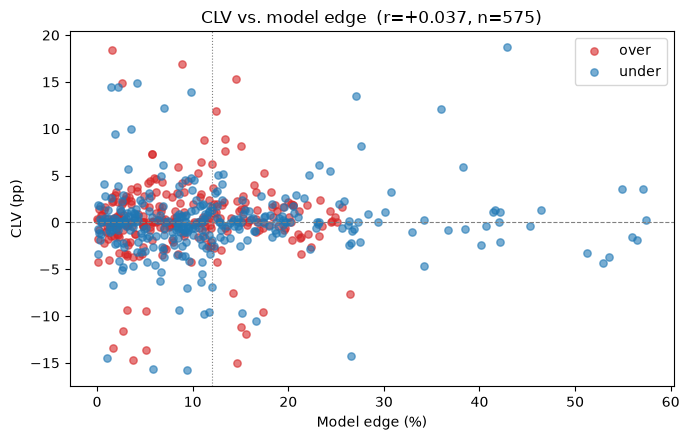

In [7]:
clv_scatter_src = full.filter(pl.col("clv_pp").is_not_null() & pl.col("edge").is_not_null())
if clv_scatter_src.height:
    pdf = clv_scatter_src.select(
        (pl.col("edge") * 100).alias("edge_pct"),
        (pl.col("clv_pp") * 100).alias("clv_pct"),
        "side",
    ).to_pandas()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for side, color in [("over", "tab:red"), ("under", "tab:blue")]:
        sub = pdf[pdf["side"] == side]
        ax.scatter(sub["edge_pct"], sub["clv_pct"], alpha=0.6, label=side, color=color, s=28)
    if len(pdf) >= 3:
        corr = pdf["edge_pct"].corr(pdf["clv_pct"])
        ax.set_title(f"CLV vs. model edge  (r={corr:+.3f}, n={len(pdf)})")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(DEFAULT_EDGE_FLOOR * 100, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("Model edge (%)")
    ax.set_ylabel("CLV (pp)")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No CLV data yet.")

## 4. Side / Book Splits

In [8]:
by_side = (
    staked.group_by("side")
    .agg(pl.len().alias("n"), pl.col("pnl").sum().round(2).alias("pnl"),
         pl.col("result").eq("win").mean().round(3).alias("win_rate"))
)
by_book = (
    staked.group_by("book")
    .agg(pl.len().alias("n"), pl.col("pnl").sum().round(2).alias("pnl"),
         pl.col("result").eq("win").mean().round(3).alias("win_rate"))
)
print("--- by side ---")
print(by_side)

side_health = side_clv_roi_health(staked)
print("\n--- side CLV/ROI health ---")
print(side_health)
if has_over_clv_red_flag(side_health):
    print("RED FLAG: over mean_clv_pp <= 0 (or missing).")

print("\n--- by book ---")
print(by_book)

print("\n--- book x edge-bin (pnl) ---")
book_edge = (
    staked_binned.group_by(["book", "edge_bin"])
    .agg(pl.len().alias("n"), pl.col("pnl").sum().round(2).alias("pnl"))
    .with_columns(pl.col("edge_bin").cast(pl.Enum(EDGE_BIN_ORDER)))
    .sort(["book", "edge_bin"])
)
print(book_edge)

--- by side ---
shape: (2, 4)
┌───────┬─────┬─────────┬──────────┐
│ side  ┆ n   ┆ pnl     ┆ win_rate │
│ ---   ┆ --- ┆ ---     ┆ ---      │
│ str   ┆ u32 ┆ f64     ┆ f64      │
╞═══════╪═════╪═════════╪══════════╡
│ over  ┆ 76  ┆ -879.67 ┆ 0.421    │
│ under ┆ 88  ┆ 952.25  ┆ 0.557    │
└───────┴─────┴─────────┴──────────┘

--- side CLV/ROI health ---
shape: (2, 6)
┌───────┬─────┬─────────────┬─────────────┬───────────┬─────────────┐
│ side  ┆ n   ┆ stake       ┆ pnl         ┆ roi       ┆ mean_clv_pp │
│ ---   ┆ --- ┆ ---         ┆ ---         ┆ ---       ┆ ---         │
│ str   ┆ u32 ┆ f64         ┆ f64         ┆ f64       ┆ f64         │
╞═══════╪═════╪═════════════╪═════════════╪═══════════╪═════════════╡
│ over  ┆ 76  ┆ 5062.103013 ┆ -879.669969 ┆ -0.173776 ┆ 0.009725    │
│ under ┆ 88  ┆ 7030.65769  ┆ 952.250803  ┆ 0.135443  ┆ 0.005232    │
└───────┴─────┴─────────────┴─────────────┴───────────┴─────────────┘

--- by book ---
shape: (2, 4)
┌────────────┬─────┬───────┬──────────┐


## 5. K-Bias / Calibration by Side

Joins each settled ticket back to its logged projection
(`artifacts/projection_log/projections.parquet`) to compare `expected_K`
against the actual `settle_value`. A positive bias means the model
over-projected strikeouts (favors `over` bets that then don't cash).

In [9]:
PROJECTIONS_PATH = ROOT / "artifacts" / "projection_log" / "projections.parquet"

if PROJECTIONS_PATH.exists() and staked.height:
    proj = (
        pl.read_parquet(PROJECTIONS_PATH)
        .with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10))
        .select(["game_date", "player_name", "expected_K"])
        .unique(subset=["game_date", "player_name"], keep="first")
    )
    joined = staked.join(proj, on=["game_date", "player_name"], how="left").filter(
        pl.col("expected_K").is_not_null() & pl.col("settle_value").is_not_null()
    )
    if joined.height:
        bias = joined.with_columns((pl.col("expected_K") - pl.col("settle_value")).alias("k_bias"))
        bias_by_side = (
            bias.group_by("side")
            .agg(
                pl.len().alias("n"),
                pl.col("k_bias").mean().round(3).alias("mean_k_bias"),
                pl.col("p_model").mean().round(3).alias("mean_p_model"),
                pl.col("result").eq("win").mean().round(3).alias("actual_win_rate"),
            )
            .with_columns((pl.col("mean_p_model") - pl.col("actual_win_rate")).round(3).alias("calibration_gap"))
        )
        print("K-bias & calibration gap by side (positive k_bias = model over-projected K):")
        print(bias_by_side)
    else:
        print("No joined rows with both expected_K and settle_value yet.")
else:
    print("Missing projections log or no staked/settled bets yet.")

K-bias & calibration gap by side (positive k_bias = model over-projected K):
shape: (2, 6)
┌───────┬─────┬─────────────┬──────────────┬─────────────────┬─────────────────┐
│ side  ┆ n   ┆ mean_k_bias ┆ mean_p_model ┆ actual_win_rate ┆ calibration_gap │
│ ---   ┆ --- ┆ ---         ┆ ---          ┆ ---             ┆ ---             │
│ str   ┆ u32 ┆ f64         ┆ f64          ┆ f64             ┆ f64             │
╞═══════╪═════╪═════════════╪══════════════╪═════════════════╪═════════════════╡
│ over  ┆ 76  ┆ 1.306       ┆ 0.643        ┆ 0.421           ┆ 0.222           │
│ under ┆ 88  ┆ -0.513      ┆ 0.676        ┆ 0.557           ┆ 0.119           │
└───────┴─────┴─────────────┴──────────────┴─────────────────┴─────────────────┘


## 5b. Calibration gap, stratified side × matchup tier

Section 5 aggregates `k_bias` and `calibration_gap` by `side` only. That tells you
**that** the model over-projects on the over side (positive `k_bias`, positive
`calibration_gap`), but not **where**. The over-side miscalibration could come
from either of two mechanisms — and they have different fixes:

1. **Projection-side miscalibration** — `expected_K` is structurally too high on
   bets where the over is the recommended side. Points at `training.py` / `k_bias`.
2. **Subset-composition asymmetry** — the over recommendation fires on a different
   *subset* of games (different opponent-quality tiers, parks, weather) than the
   under, and the miscalibration lives in the subset, not the side. The fix is the
   subset, not `k_bias`.

This section stratifies the Section 5 gap by `opp_lineup_k_vs_hand` tier **within**
each side. If the gap concentrates in one matchup tier of one side, mechanism (2)
— and **the matchup-tier invert from Section 9 is probably the same bug viewed
through a second lens.** If the gap is uniform across tiers within the over side,
mechanism (1) → go to `training.py` with that diagnosis.

This section re-uses Section 0's `clv_version_map.parquet` so it benefits from the
model-version partition for free — if the cells are filtered to a single SHA the
stratification re-runs against a single freeze and the over-side question doesn't
average across model versions.

Stratified k-bias / calibration gap (side x matchup tier):
shape: (6, 8)
┌───────┬───────────────────┬─────┬─────────────┬──────────────┬─────────────────┬──────────┬───────┐
│ side  ┆ matchup_tier      ┆ n   ┆ mean_k_bias ┆ mean_p_model ┆ actual_win_rate ┆ mean_gap ┆ n_clv │
│ ---   ┆ ---               ┆ --- ┆ ---         ┆ ---          ┆ ---             ┆ ---      ┆ ---   │
│ str   ┆ cat               ┆ u32 ┆ f64         ┆ f64          ┆ f64             ┆ f64      ┆ u32   │
╞═══════╪═══════════════════╪═════╪═════════════╪══════════════╪═════════════════╪══════════╪═══════╡
│ over  ┆ avg_matchup       ┆ 26  ┆ 1.528       ┆ 0.642        ┆ 0.462           ┆ 0.18     ┆ 20    │
│ over  ┆ favorable_matchup ┆ 25  ┆ 1.363       ┆ 0.649        ┆ 0.32            ┆ 0.329    ┆ 20    │
│ over  ┆ weak_matchup      ┆ 25  ┆ 1.018       ┆ 0.637        ┆ 0.48            ┆ 0.157    ┆ 20    │
│ under ┆ avg_matchup       ┆ 28  ┆ -0.51       ┆ 0.675        ┆ 0.607           ┆ 0.068    ┆ 22    │
│ under ┆

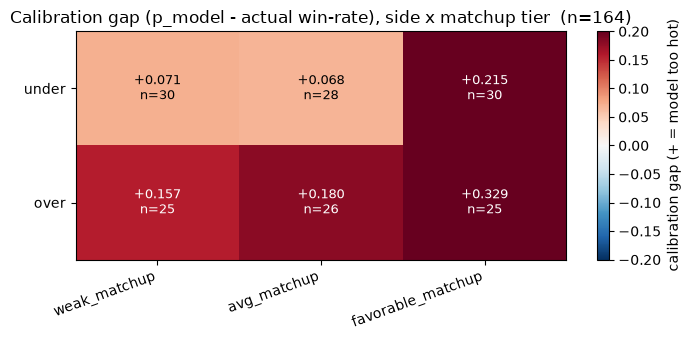

In [10]:
# Section 5b: stratified calibration gap (side x matchup tier).
#
# Re-uses the proj join pattern from Section 5 but reads opp_lineup_k_vs_hand
# from the projection log too, then splits the side-level gap by tier.
#
# Optional model-version filter: if you only want to interrogate one freeze
# (e.g. the post-Platt-calibration era), set VERSION_FILTER to the leading 8
# chars of the k_rate SHA from Section 0; None means use the whole settled
# universe.

VERSION_FILTER = None  # e.g. "ab12cd34"  (set from Section 0's lead-version table)

_opp_cols_5b = [
    c for c in (
        "game_date",
        "player_name",
        "expected_K",
        "opp_lineup_k",
        "opp_lineup_k_vs_hand",
        "k_rate_sha256",
    )
    if c in pl.scan_parquet(PROJECTIONS_PATH).collect_schema().names()
]

if PROJECTIONS_PATH.exists() and staked.height:
    _proj5b = (
        pl.read_parquet(PROJECTIONS_PATH)
        .with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date"))
        .select(_opp_cols_5b)
        .unique(subset=["game_date", "player_name"], keep="first")
    )
    joined5b = staked.join(_proj5b, on=["game_date", "player_name"], how="left").filter(
        pl.col("expected_K").is_not_null()
        & pl.col("settle_value").is_not_null()
        & pl.col("opp_lineup_k_vs_hand").is_not_null()
        & pl.col("side").is_not_null()
    )

    # Optional version filter (set VERSION_FILTER above to a leading 8-char SHA).
    if VERSION_FILTER is not None and "k_rate_sha256" in joined5b.columns:
        joined5b = joined5b.filter(
            pl.col("k_rate_sha256").cast(pl.Utf8).str.slice(0, 8) == VERSION_FILTER
        )
        print(f"filtered to k_rate_sha256 startswith {VERSION_FILTER!r} -> n={joined5b.height}")

    if joined5b.height >= 12:
        # 3-tier qcut on opp_lineup_k_vs_hand (matches Section 9 labels).
        _tiered5b = joined5b.with_columns(
            (pl.col("expected_K") - pl.col("settle_value")).alias("k_bias"),
            (pl.col("p_model") - pl.col("result").eq("win").cast(pl.Float64)).round(3).alias("calibration_gap"),
            pl.col("opp_lineup_k_vs_hand").qcut(
                3, labels=["weak_matchup", "avg_matchup", "favorable_matchup"]
            ).alias("matchup_tier"),
        )

        gap_stratified = (
            _tiered5b.group_by(["side", "matchup_tier"])
            .agg(
                pl.len().alias("n"),
                pl.col("k_bias").mean().round(3).alias("mean_k_bias"),
                pl.col("p_model").mean().round(3).alias("mean_p_model"),
                pl.col("result").eq("win").mean().round(3).alias("actual_win_rate"),
                pl.col("calibration_gap").mean().round(3).alias("mean_gap"),
                pl.col("clv_pp").count().alias("n_clv"),
            )
            .sort(["side", "matchup_tier"])
        )
        print("Stratified k-bias / calibration gap (side x matchup tier):")
        with pl.Config(tbl_cols=-1, tbl_width_chars=220):
            print(gap_stratified)

        # Where's the over-side gap actually coming from? Concentration test.
        over = _tiered5b.filter(pl.col("side") == "over")
        if over.height:
            over_by_tier = over.group_by("matchup_tier").agg(
                pl.len().alias("n"),
                pl.col("calibration_gap").sum().round(3).alias("gap_sum"),
            ).sort("gap_sum", descending=True)
            top_tier = over_by_tier.row(0, named=True)
            tot = over_by_tier["gap_sum"].abs().sum() or 1.0
            share = abs(top_tier["gap_sum"]) / tot
            print(
                f"\nover-side gap is most concentrated in tier "
                f"'{top_tier['matchup_tier']}' ({top_tier['gap_sum']:+.3f} on "
                f"n={top_tier['n']}; {share:.0%} of the over-side abs-gap)."
            )
            print(
                "  -> Concentrated in one tier: mechanism (2) (subset-composition). "
                "Cross-check Section 9's matchup tier to confirm the matchup-tier "
                "invert is the same bug."
                if share >= 0.6
                else "  -> Spread across tiers: mechanism (1) (projection-side k_bias). "
                "Take the diagnosis to training.py."
            )

        # Heatmap: side x tier cells colored by calibration_gap (the diagnostic).
        import pandas as _pd  # local-only

        # Build (side, tier) -> n lookup once so the per-cell annotation is cheap
        # and immune to gap_stratified's shape changing across versions.
        n_lookup = {
            (r["side"], r["matchup_tier"]): int(r["n"])
            for r in gap_stratified.iter_rows(named=True)
        }

        _pivot = (
            gap_stratified.select("side", "matchup_tier", "mean_gap")
            .to_pandas()
            .pivot(index="side", columns="matchup_tier", values="mean_gap")
            .reindex(index=["under", "over"],
                     columns=["weak_matchup", "avg_matchup", "favorable_matchup"])
        )
        fig, ax = plt.subplots(figsize=(7, 3.5))
        im = ax.imshow(_pivot.values, cmap="RdBu_r", vmin=-0.20, vmax=0.20, aspect="auto")
        ax.set_xticks(range(_pivot.shape[1])); ax.set_xticklabels(_pivot.columns, rotation=20, ha="right")
        ax.set_yticks(range(_pivot.shape[0])); ax.set_yticklabels(_pivot.index)
        for i in range(_pivot.shape[0]):
            for j in range(_pivot.shape[1]):
                v = _pivot.values[i, j]
                n_cell = n_lookup.get((_pivot.index[i], _pivot.columns[j]), 0)
                label = f"{v:+.3f}\nn={n_cell}" if (v == v) else f"n={n_cell}"
                ax.text(j, i, label, ha="center", va="center", fontsize=9,
                        color="white" if abs(v or 0) > 0.10 else "black")
        ax.set_title(f"Calibration gap (p_model - actual win-rate), side x matchup tier  (n={joined5b.height})")
        fig.colorbar(im, ax=ax, label="calibration gap (+ = model too hot)")
        plt.tight_layout(); plt.show()
    else:
        print(f"need >= 12 staked bets with both expected_K and opp_lineup_k_vs_hand "
              f"(have {joined5b.height}); cannot stratify.")
else:
    print("Missing projections log or no staked/settled bets yet.")

## 6. Kelly vs. Flat Sizing Comparison

Re-derives PnL for each settled/staked ticket under three alternate sizing
rules, using the ticket's **actual recorded open price** and real outcome
(`result`) — only the stake changes:

- **actual (fractional Kelly)**: what was really staked (`stake` column)
- **flat_1u**: every bet sized at exactly 1 unit (`unit_dollars`)
- **flat_1.5x_20plus**: 1u, except 1.5u when model edge >= 20%
- **flat_2x_20plus**: 1u, except 2.0u when model edge >= 20%

In [11]:
def scenario_pnl(df: pl.DataFrame, boost_mult: float | None) -> pl.DataFrame:
    won = pl.col("result") == "win"
    if boost_mult is None:
        stake_expr = pl.col("unit_dollars")
    else:
        stake_expr = pl.when(pl.col("edge") >= 0.20).then(pl.col("unit_dollars") * boost_mult).otherwise(pl.col("unit_dollars"))
    dec = pl.when(pl.col("bet_price") > 0).then(pl.col("bet_price") / 100 + 1).otherwise(100 / (-pl.col("bet_price")) + 1)
    pnl_expr = pl.when(won).then(stake_expr * (dec - 1)).otherwise(-stake_expr)
    return df.with_columns(stake_expr.alias("_scn_stake"), pnl_expr.alias("_scn_pnl"))

scenarios = {
    "actual_kelly": None,
    "flat_1u": None,
    "flat_1.5x_20plus": 1.5,
    "flat_2x_20plus": 2.0,
}

rows = []
base = staked.filter(pl.col("unit_dollars").is_not_null() & pl.col("bet_price").is_not_null())
for name, boost in scenarios.items():
    if name == "actual_kelly":
        pnl_sum = float(base["pnl"].sum())
        stake_sum = float(base["stake"].sum())
    else:
        scn = scenario_pnl(base, boost)
        pnl_sum = float(scn["_scn_pnl"].sum())
        stake_sum = float(scn["_scn_stake"].sum())
    roi = pnl_sum / stake_sum * 100 if stake_sum else float("nan")
    rows.append({"scenario": name, "n": base.height, "total_staked": round(stake_sum, 2),
                 "total_pnl": round(pnl_sum, 2), "roi_pct": round(roi, 2)})

scenario_tbl = pl.DataFrame(rows)
print(scenario_tbl)
print(
    f"\nNote: flat scenarios keep the same {DEFAULT_EDGE_FLOOR*100:.0f}% edge floor "
    "for bet selection - only the stake formula changes."
)

shape: (4, 5)
┌──────────────────┬─────┬──────────────┬───────────┬─────────┐
│ scenario         ┆ n   ┆ total_staked ┆ total_pnl ┆ roi_pct │
│ ---              ┆ --- ┆ ---          ┆ ---       ┆ ---     │
│ str              ┆ i64 ┆ f64          ┆ f64       ┆ f64     │
╞══════════════════╪═════╪══════════════╪═══════════╪═════════╡
│ actual_kelly     ┆ 164 ┆ 12092.76     ┆ 72.58     ┆ 0.6     │
│ flat_1u          ┆ 164 ┆ 8200.0       ┆ -300.36   ┆ -3.66   │
│ flat_1.5x_20plus ┆ 164 ┆ 9425.0       ┆ -84.8     ┆ -0.9    │
│ flat_2x_20plus   ┆ 164 ┆ 10650.0      ┆ 130.75    ┆ 1.23    │
└──────────────────┴─────┴──────────────┴───────────┴─────────┘

Note: flat scenarios keep the same 12% edge floor for bet selection - only the stake formula changes.


## 7. Bankroll / Cumulative PnL Curve

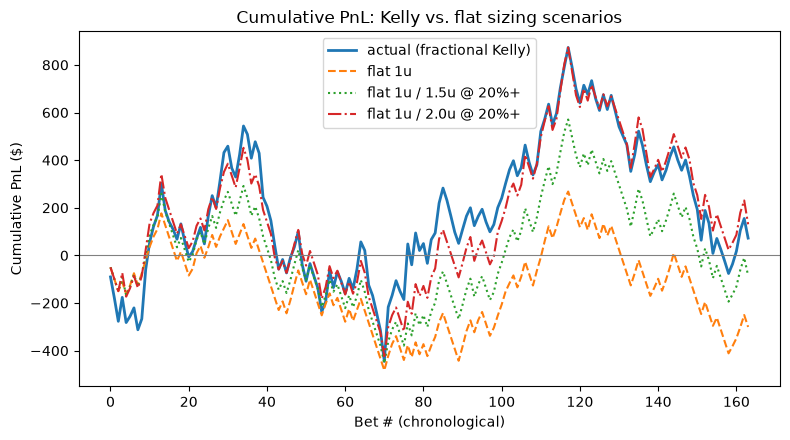

In [12]:
if base.height:
    sort_col = "closed_at_utc" if "closed_at_utc" in base.columns else "game_date"
    ordered = base.sort(["game_date", sort_col])
    pdf = ordered.select("game_date", "pnl").to_pandas()
    pdf["cum_actual"] = pdf["pnl"].cumsum()

    for name, boost in [("flat_1u", None), ("flat_1.5x_20plus", 1.5), ("flat_2x_20plus", 2.0)]:
        scn = scenario_pnl(ordered, boost).select("_scn_pnl").to_pandas()
        pdf[f"cum_{name}"] = scn["_scn_pnl"].cumsum()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = range(len(pdf))
    ax.plot(x, pdf["cum_actual"], label="actual (fractional Kelly)", linewidth=2)
    ax.plot(x, pdf["cum_flat_1u"], label="flat 1u", linestyle="--")
    ax.plot(x, pdf["cum_flat_1.5x_20plus"], label="flat 1u / 1.5u @ 20%+", linestyle=":")
    ax.plot(x, pdf["cum_flat_2x_20plus"], label="flat 1u / 2.0u @ 20%+", linestyle="-.")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Bet # (chronological)")
    ax.set_ylabel("Cumulative PnL ($)")
    ax.set_title("Cumulative PnL: Kelly vs. flat sizing scenarios")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No staked/settled bets yet.")

## 8. Rolling CLV Trend

Rolling mean CLV over the last 20 / 50 props (chronological), against the
zero line. Watch whether this drifts up/down as sample size grows toward the
`n_clv >= 100` gate.

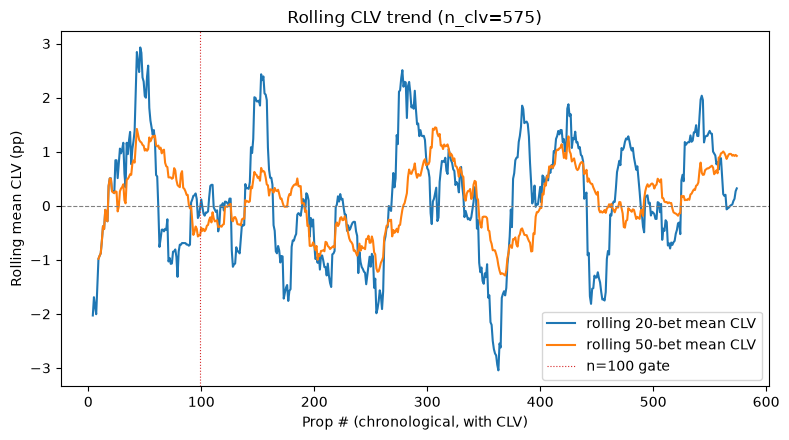

In [13]:
clv_ordered = full.filter(pl.col("clv_pp").is_not_null()).sort(["game_date", "closed_at_utc"] if "closed_at_utc" in full.columns else ["game_date"])
if clv_ordered.height >= 5:
    pdf = clv_ordered.select((pl.col("clv_pp") * 100).alias("clv_pct")).to_pandas()
    pdf["roll20"] = pdf["clv_pct"].rolling(20, min_periods=5).mean()
    pdf["roll50"] = pdf["clv_pct"].rolling(50, min_periods=10).mean()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(pdf.index, pdf["roll20"], label="rolling 20-bet mean CLV")
    ax.plot(pdf.index, pdf["roll50"], label="rolling 50-bet mean CLV")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(min(MIN_CLV_N, len(pdf)) - 1, color="tab:red", linewidth=0.8, linestyle=":", label=f"n={MIN_CLV_N} gate")
    ax.set_xlabel("Prop # (chronological, with CLV)")
    ax.set_ylabel("Rolling mean CLV (pp)")
    ax.set_title(f"Rolling CLV trend (n_clv={len(pdf)})")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Not enough CLV data yet for a rolling trend (need >= 5).")

## 9. Opponent Quality & Home/Away Splits

`opp_lineup_k_vs_hand` is the opponent lineup's K rate specifically against a
pitcher throwing the same hand as the starter that game (i.e. it's already
handedness-aware) - binning on it directly tells us whether we're getting
paid for attacking favorable platoon matchups, independent of raw opponent
strikeout rate (`opp_lineup_k`).

In [14]:
if PROJECTIONS_PATH.exists() and staked.height:
    opp_cols = [
        c
        for c in ("game_date", "player_name", "is_home", "opp_lineup_k", "opp_lineup_k_vs_hand")
        if c in pl.scan_parquet(PROJECTIONS_PATH).collect_schema().names()
    ]
    opp = (
        pl.read_parquet(PROJECTIONS_PATH)
        .with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10))
        .select(opp_cols)
        .unique(subset=["game_date", "player_name"], keep="first")
    )
    staked_opp = staked.join(opp, on=["game_date", "player_name"], how="left")

    if "is_home" in staked_opp.columns:
        home_away = (
            staked_opp.filter(pl.col("is_home").is_not_null())
            .group_by("is_home")
            .agg(
                pl.len().alias("n"),
                pl.col("pnl").sum().round(2).alias("pnl"),
                pl.col("result").eq("win").mean().round(3).alias("win_rate"),
                pl.col("clv_pp").mean().alias("mean_clv_pct"),
            )
            .with_columns((pl.col("mean_clv_pct") * 100).round(3))
            .sort("is_home")
        )
        print("--- home vs. away starter ---")
        print(home_away)

    if "opp_lineup_k_vs_hand" in staked_opp.columns:
        matchup = staked_opp.filter(pl.col("opp_lineup_k_vs_hand").is_not_null())
        if matchup.height >= 8:
            matchup = matchup.with_columns(
                pl.col("opp_lineup_k_vs_hand")
                .qcut(3, labels=["weak_matchup", "avg_matchup", "favorable_matchup"])
                .alias("matchup_tier")
            )
            matchup_tbl = (
                matchup.group_by("matchup_tier")
                .agg(
                    pl.len().alias("n"),
                    pl.col("pnl").sum().round(2).alias("pnl"),
                    pl.col("result").eq("win").mean().round(3).alias("win_rate"),
                    pl.col("clv_pp").mean().alias("mean_clv_pct"),
                    pl.col("opp_lineup_k_vs_hand").mean().round(4).alias("avg_opp_k_vs_hand"),
                )
                .with_columns((pl.col("mean_clv_pct") * 100).round(3))
                .sort("matchup_tier")
            )
            print("\n--- opponent-quality tiers (opp K rate vs. this pitcher's hand) ---")
            print(matchup_tbl)
        else:
            print("\nNeed >= 8 staked bets with opp_lineup_k_vs_hand to form tiers.")
else:
    print("Missing projections log or no staked/settled bets yet.")

--- home vs. away starter ---
shape: (2, 5)
┌─────────┬─────┬────────┬──────────┬──────────────┐
│ is_home ┆ n   ┆ pnl    ┆ win_rate ┆ mean_clv_pct │
│ ---     ┆ --- ┆ ---    ┆ ---      ┆ ---          │
│ bool    ┆ u32 ┆ f64    ┆ f64      ┆ f64          │
╞═════════╪═════╪════════╪══════════╪══════════════╡
│ false   ┆ 84  ┆ 105.62 ┆ 0.5      ┆ 0.998        │
│ true    ┆ 80  ┆ -33.04 ┆ 0.488    ┆ 0.499        │
└─────────┴─────┴────────┴──────────┴──────────────┘

--- opponent-quality tiers (opp K rate vs. this pitcher's hand) ---
shape: (3, 6)
┌───────────────────┬─────┬─────────┬──────────┬──────────────┬───────────────────┐
│ matchup_tier      ┆ n   ┆ pnl     ┆ win_rate ┆ mean_clv_pct ┆ avg_opp_k_vs_hand │
│ ---               ┆ --- ┆ ---     ┆ ---      ┆ ---          ┆ ---               │
│ cat               ┆ u32 ┆ f64     ┆ f64      ┆ f64          ┆ f64               │
╞═══════════════════╪═════╪═════════╪══════════╪══════════════╪═══════════════════╡
│ avg_matchup       ┆ 54  ┆ 6

## 10. Edge-Floor Sweep — whole settled universe, flat-1u vs. Kelly

**Why two ROI curves, not one.** Kelly-stake ROI (`sum(pnl) / sum(stake) %`) reflects your
*realized bankroll* — that's the official answer to "did I make money." But it
**mixes two effects into one variable**: bet selection (which bets fire) and
bet sizing (how big each bet is). Choose-Kelly means a single high-edge
leverage bet can dominate the sum; raising the floor then changes the
denominator as much as the numerator. That makes Kelly ROI a *bad* navigator
for setting an edge floor, which is fundamentally a per-bet yes/no decision.

Flat-1u-risked ROI fixes this: **every settled bet counts as exactly $1
risked regardless of edge or odds.** A win pays `(dec − 1) × $1`, a loss
costs `$1`. A −160 favorite loss costs $1, a +120 dog win pays $1.20;
favorites and dogs are penalized equally on a dollar-cost-of-loss basis.
Each bet contributes equally to the estimate, so the curve answers
"if I'd fired flat-1u on every settled bet with edge ≥ floor, what's my
ROI?" — that's the per-bet skill question the floor is supposed to control.

**The sweep covers the whole settled universe (including sub-floor observations).**
The previous version filtered to `stake > 0`, which silently excluded any
bet Kelly's edge-floor rule declined — that's the very range we need to
inspect when validating whether the *current* floor is set correctly. Now the
flat-1u curve runs over *all* graded-settled tickets including those Kelly
passed on, so sub-floor behavior is visible.

**How to read the two curves together:**
- **Flat (red) line crosses 0**: the *per-bet skill break-even* floor.
  Should match DEFAULT_EDGE_FLOOR if the floor is set correctly.
- **Kelly (blue) line vs flat (red) line gap at any floor**: theKelly
  sizing premium/discount at that floor. If Kelly >> flat, Kelly is
  concentrating stake on a few winners (often small-n luck, not skill).
  If Kelly << flat, Kelly's high-edge stakes are dragging (variance, not
  wrong-side selection).
- **A high-floor "Kelly ROI explosion" with flat ROI going flat/negative
  is a variance mirage** — high-edge small-n buckets where Kelly happened
  to land a few big wins. Trust the flat line for floor-setting.

**Chart B (right):** finer CLV-by-edge-bin with bootstrap 95% CIs — the
skill oracle per bin. CLV positive across bins is the prerequisite for
proven skill; if CLV turns negative at the high edges while PnL goes up,
*the market says the high-edge PnL is luck, not skill.* Trust CLV over
PnL when small-n at high floors.

> Caveats:
> - The pre-registered skill gate (`n_clv ≥ 100`, bootstrap CI > 0) from
>   `docs/reference/market_clv_gates.md` still applies at the overall level.
>   Bin-level CIs are directional, not proof.
> - The 6 settled-but-missing-CLV tickets (SharpAPI gaps) skew slightly
>   toward late-posted / lower-liquidity props — a minor selection bias.

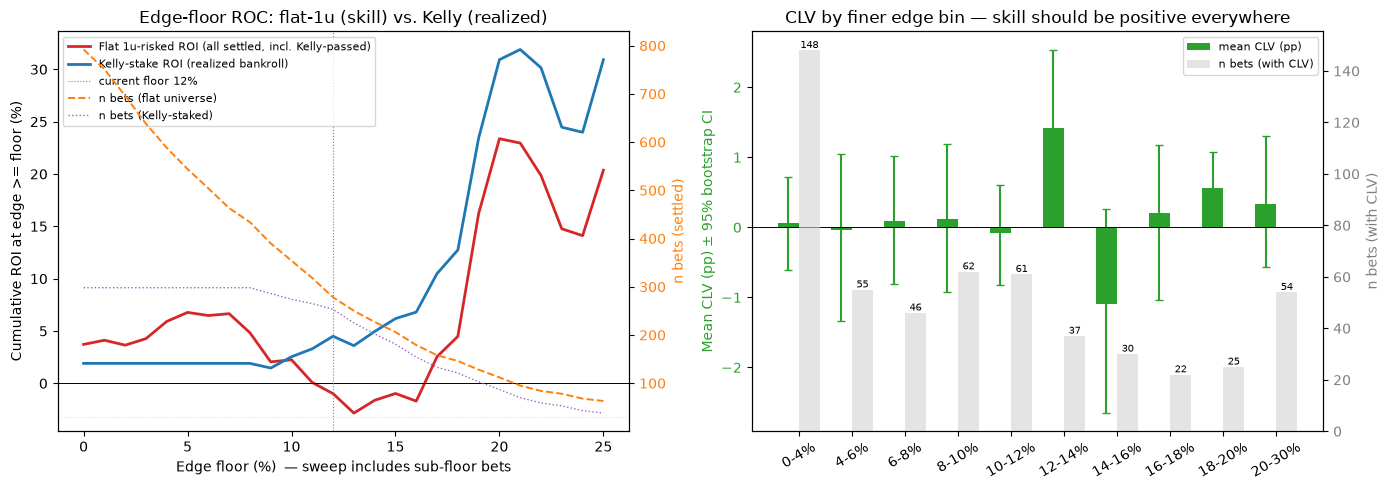


--- Edge-floor ROC: full dataset (including sub-floor observations) ---


floor_pct,n_kelly,n_flat,n_clv,kelly_pnl,kelly_stake,kelly_roi_pct,flat_1u_pnl,flat_1u_roi_pct,flat_wins,flat_win_rate,mean_clv_pp,clv_lo,clv_hi
f64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
0.0,298,792,567,426.442457,22356.264127,1.91,29.45637,3.72,431,0.544,0.168,-0.138,0.495
1.0,298,751,539,426.442457,22356.264127,1.91,30.936798,4.12,410,0.546,0.179,-0.169,0.515
2.0,298,696,501,426.442457,22356.264127,1.91,25.384947,3.65,377,0.542,0.178,-0.146,0.519
3.0,298,638,455,426.442457,22356.264127,1.91,27.262226,4.27,348,0.545,0.167,-0.184,0.516
4.0,298,588,419,426.442457,22356.264127,1.91,34.787638,5.92,326,0.554,0.206,-0.143,0.551
…,…,…,…,…,…,…,…,…,…,…,…,…,…
21.0,70,95,70,2669.58143,8370.576227,31.89,21.806824,22.95,60,0.632,0.503,-0.479,1.55
22.0,59,84,63,2189.189355,7261.28579,30.15,16.680226,19.86,52,0.619,0.564,-0.549,1.79
23.0,53,78,58,1612.428521,6589.882292,24.47,11.516076,14.76,46,0.59,0.653,-0.474,1.863


In [15]:
import numpy as np

# Two parallel sources (both loaded directly via `full = load_ledger()`):
#   * kelly_src  = tickets Kelly actually staked on (stake > 0). Used for the
#                  blue "Kelly PnL" curve so it reflects realized bankroll.
#   * flat_src   = ALL settled tickets, INCLUDING those Kelly passed on
#                  (stake == 0). Flat-1u-risked PnL is computed uniformly so
#                  we can sweep floor candidates the live sizing filter would
#                  have skipped. This is the curve that tests whether the
#                  configured floor is set correctly.
settled_all = settled_bets(full).filter(pl.col("edge").is_not_null())
kelly_src = settled_all.filter(pl.col("stake") > 0)
flat_src = settled_all

# Flat 1u-risked PnL: win -> +1 * (dec - 1); loss -> -1.
# dec-1 = bet_price/100 if bet_price > 0 else 100/(-bet_price).
# A -160 loss costs $1.00 (1u risked), a +120 win pays $1.20, all bets use
# the same $1 risked regardless of odds -- so favorites and dogs are
# penalized equally on a dollar-cost-of-loss basis.
flat_pnl_expr = (
    pl.when(pl.col("result") == "win")
    .then(
        pl.when(pl.col("bet_price") > 0)
        .then(pl.col("bet_price") / 100.0)
        .otherwise(100.0 / (-pl.col("bet_price")))
    )
    .otherwise(-1.0)
    .alias("flat_1u_pnl")
)
flat_src = flat_src.with_columns(flat_pnl_expr)

# ---- Edge-floor ROC sweep ----
FLOORS = np.arange(0, 26, 1)  # 0% .. 25% in 1-point steps
rows = []
for f in FLOORS:
    k = kelly_src.filter(pl.col("edge") * 100 >= f)
    fl = flat_src.filter(pl.col("edge") * 100 >= f)
    n_kelly = k.height
    n_flat = fl.height
    k_pnl = float(k["pnl"].sum()) if n_kelly else 0.0
    k_stake = float(k["stake"].sum()) if n_kelly else 0.0
    k_roi = (k_pnl / k_stake * 100) if k_stake else float("nan")
    fl_pnl = float(fl["flat_1u_pnl"].sum()) if n_flat else 0.0
    # Flat-1u risked = 1.0 per bet, so denominator = n_flat.
    fl_roi = (fl_pnl / n_flat * 100) if n_flat else float("nan")
    # Win/loss counts (flat universe) for an un-staked-skill sanity check.
    fl_wins = int(fl.filter(pl.col("result") == "win").height)
    clv_sub = flat_src.filter(pl.col("edge") * 100 >= f, pl.col("clv_pp").is_not_null())
    clvs = [float(x) for x in clv_sub["clv_pp"].to_list()] if clv_sub.height else []
    if len(clvs) >= 5:
        m, lo, hi = bootstrap_mean_ci(clvs)
        clv_lo, clv_hi, clv_mean = lo * 100, hi * 100, m * 100
    else:
        clv_mean, clv_lo, clv_hi = float("nan"), float("nan"), float("nan")
    rows.append(
        {
            "floor_pct": float(f),
            "n_kelly": n_kelly,
            "n_flat": n_flat,
            "n_clv": len(clvs),
            "kelly_pnl": k_pnl,
            "kelly_stake": k_stake,
            "kelly_roi_pct": k_roi,
            "flat_1u_pnl": fl_pnl,
            "flat_1u_roi_pct": fl_roi,
            "flat_wins": fl_wins,
            "flat_win_rate": (fl_wins / n_flat) if n_flat else float("nan"),
            "mean_clv_pp": clv_mean,
            "clv_lo": clv_lo,
            "clv_hi": clv_hi,
        }
    )

roc = pl.DataFrame(rows)
pd_roc = roc.to_pandas()

# ---- Chart B: finer CLV-by-edge-bin with 95% bootstrap CIs ----
FINER_BINS = [(0, 4), (4, 6), (6, 8), (8, 10), (10, 12), (12, 14),
              (14, 16), (16, 18), (18, 20), (20, 30)]
b_centers, b_clv, b_lo, b_hi, b_n = [], [], [], [], []
clv_src = settled_all.filter(pl.col("clv_pp").is_not_null())
for lo_e, hi_e in FINER_BINS:
    sub = clv_src.filter(
        (pl.col("edge") * 100 >= lo_e) & (pl.col("edge") * 100 < hi_e)
    )
    if sub.height == 0:
        continue
    clvs = [float(x) for x in sub["clv_pp"].to_list()]
    if len(clvs) >= 5:
        m, lo, hi = bootstrap_mean_ci(clvs)
    else:
        m = sum(clvs) / len(clvs) if clvs else float("nan")
        lo = hi = float("nan")
    b_centers.append((lo_e + hi_e) / 2)
    b_clv.append(m * 100)
    b_lo.append(lo * 100 if lo == lo else float("nan"))
    b_hi.append(hi * 100 if hi == hi else float("nan"))
    b_n.append(sub.height)

# ---- Render side-by-side ----
if pd_roc["n_flat"].max() or b_centers:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: two ROI curves vs edge floor
    ax1.plot(pd_roc["floor_pct"], pd_roc["flat_1u_roi_pct"], color="tab:red",
             lw=2, label="Flat 1u-risked ROI (all settled, incl. Kelly-passed)")
    ax1.plot(pd_roc["floor_pct"], pd_roc["kelly_roi_pct"], color="tab:blue",
             lw=2, label="Kelly-stake ROI (realized bankroll)")
    ax1.axhline(0, color="black", lw=0.7)
    ax1.axvline(DEFAULT_EDGE_FLOOR * 100, color="gray", lw=0.8, linestyle=":",
                label=f"current floor {DEFAULT_EDGE_FLOOR * 100:.0f}%")
    ax1.set_xlabel("Edge floor (%)  — sweep includes sub-floor bets")
    ax1.set_ylabel("Cumulative ROI at edge >= floor (%)")
    ax1.set_title("Edge-floor ROC: flat-1u (skill) vs. Kelly (realized)")
    ax1.legend(loc="upper left", fontsize=8)

    ax1b = ax1.twinx()
    ax1b.plot(pd_roc["floor_pct"], pd_roc["n_flat"], color="tab:orange",
              lw=1.4, linestyle="--", label="n bets (flat universe)")
    ax1b.plot(pd_roc["floor_pct"], pd_roc["n_kelly"], color="tab:purple",
              lw=1.0, linestyle=":", label="n bets (Kelly-staked)")
    ax1b.axhline(30, color="tab:orange", lw=0.5, linestyle=":", alpha=0.5)
    ax1b.set_ylabel("n bets (settled)", color="tab:orange")
    ax1b.tick_params(axis="y", labelcolor="tab:orange")
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax1b.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)

    # Right: CLV by finer edge bin with CI error bars
    if b_centers:
        x = np.arange(len(b_centers))
        clv_arr = np.array(b_clv, dtype=float)
        lo_arr = np.array(b_lo, dtype=float)
        hi_arr = np.array(b_hi, dtype=float)

        ax2.bar(x - 0.2, clv_arr, width=0.4, color="tab:green",
                label="mean CLV (pp)")
        mask = ~(np.isnan(lo_arr) | np.isnan(hi_arr))
        if mask.any():
            ax2.errorbar(
                (x - 0.2)[mask], clv_arr[mask],
                yerr=[clv_arr[mask] - lo_arr[mask], hi_arr[mask] - clv_arr[mask]],
                fmt="none", ecolor="tab:green", capsize=3,
            )
        ax2.axhline(0, color="black", lw=0.7)
        ax2.set_xticks(x)
        ax2.set_xticklabels(
            [f"{lo_e}-{hi_e}%" for lo_e, hi_e in FINER_BINS if (lo_e+hi_e)/2 in b_centers],
            rotation=30,
        )
        ax2.set_ylabel("Mean CLV (pp) ± 95% bootstrap CI", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")
        ax2.set_title("CLV by finer edge bin — skill should be positive everywhere")

        ax2b = ax2.twinx()
        ax2b.bar(x + 0.2, b_n, width=0.4, color="lightgray",
                 alpha=0.6, label="n bets (with CLV)")
        ax2b.set_ylabel("n bets (with CLV)", color="gray")
        ax2b.tick_params(axis="y", labelcolor="gray")
        for xi, ni in zip(x, b_n):
            ax2b.text(xi + 0.2, ni, str(ni), ha="center", va="bottom", fontsize=7)
        h1, l1 = ax2.get_legend_handles_labels()
        h2, l2 = ax2b.get_legend_handles_labels()
        ax2.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

    fig.tight_layout()
    plt.show()
else:
    print("Not enough settled bets with edge to compute the edge-floor charts.")

# Print the full ROC table. Use with_columns to round without dropping cols.
roc_display = roc.with_columns(
    pl.col("floor_pct").round(0),
    pl.col("kelly_roi_pct").round(2),
    pl.col("flat_1u_roi_pct").round(2),
    pl.col("flat_win_rate").round(3),
    pl.col("mean_clv_pp").round(3),
    pl.col("clv_lo").round(3),
    pl.col("clv_hi").round(3),
)
print("\n--- Edge-floor ROC: full dataset (including sub-floor observations) ---")
roc_display

## 11. CLV-vs-realized-win-rate calibration (reliability plot + z-test)

The headline split between high-CLV and low-CLV cohorts is one of the strongest
signals in this ledger, but it is sample-size sensitive and should be treated as
a rolling diagnostic, not a fixed historical fact. This section keeps that read
honest in two ways:

1. **Reliability plot**: bin settled bets by `clv_pp` decile, plot observed
   win rate per bin against the CLV-predicted win rate (Brier-style). A CLV
   oracle worth trusting should show wins clustering in the right tail and a
   monotonic curve above the 45° line. If the right tail is monotonic it's a
   skill oracle; if it's driven by two outlier bins the headline gap is
   variance, not edge.
2. **Two-proportion z-test head-to-head**: `two_proportion_z_test` (in
   `src/Python/skill_stats.py`) directly tests H0: `p_win(CLV≥+1.0pp) ==
   p_win(CLV<+1.0pp)`. Read this as a *current snapshot* with uncertainty,
   not as a permanent pass/fail claim.

The weekly reliability artifact at `artifacts/odds_log/clv_reliability.parquet`
(one row per clv_pp bin with observed vs expected win rate and n) is written
here so the calibration check is persistent, not a one-off.

clv_reliability.parquet written: 10 bins, n=567
z-test: z=+1.209, p_two_sided=0.2267
  CLV>=+1.0pp: 0.560 (n=175, wins=98)
  CLV< +1.0pp: 0.505 (n=392, wins=198)


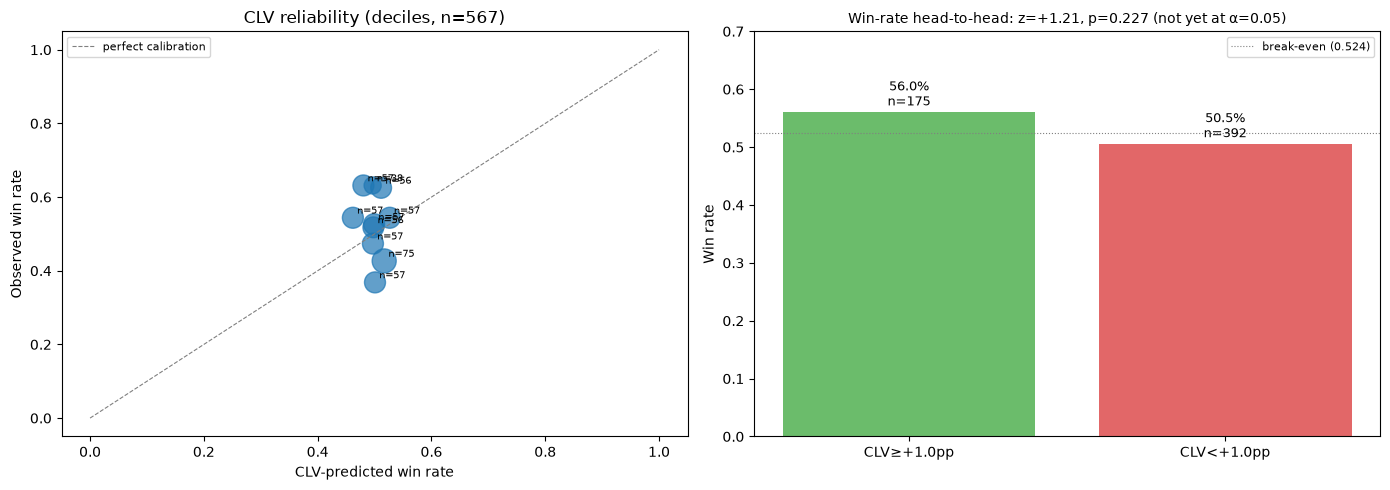


--- clv_reliability.parquet (decile-level calibration) ---
shape: (10, 5)
┌─────────────────────────────────┬─────┬───────────────────┬─────────────┬───────────────────┐
│ bin                             ┆ n   ┆ observed_win_rate ┆ mean_clv_pp ┆ expected_win_rate │
│ ---                             ┆ --- ┆ ---               ┆ ---         ┆ ---               │
│ cat                             ┆ u32 ┆ f64               ┆ f64         ┆ f64               │
╞═════════════════════════════════╪═════╪═══════════════════╪═════════════╪═══════════════════╡
│ (-inf, -3.0539218615520425]     ┆ 57  ┆ 0.54386           ┆ -6.693473   ┆ 0.461924          │
│ (-3.0539218615520425, -1.56489… ┆ 57  ┆ 0.631579          ┆ -2.20304    ┆ 0.480386          │
│ (-1.564893930347242, -0.749270… ┆ 56  ┆ 0.517857          ┆ -1.087888   ┆ 0.497903          │
│ (-0.7492705806952916, -0.25341… ┆ 57  ┆ 0.368421          ┆ -0.479716   ┆ 0.500783          │
│ (-0.25341904318652236, 0]       ┆ 75  ┆ 0.426667          ┆

In [16]:
from Python.market import american_to_implied_prob, devig_two_way
from Python.skill_stats import two_proportion_z_test

RELIABILITY_PATH = LEDGER_PATH.parent / "clv_reliability.parquet"

settled_with_clv = (
    settled_bets(full)
    .filter(pl.col("clv_pp").is_not_null() & pl.col("result").is_not_null())
    if not full.is_empty() else full
)
if not settled_with_clv.is_empty() and settled_with_clv.height >= 10:
    # ---- Reliability: bin by clv_pp decile, observed vs CLV-predicted win rate ----
    src = settled_with_clv.with_columns(
        (pl.col("clv_pp") * 100.0).alias("clv_pp_100"),
        (pl.col("result") == "win").alias("won"),
    ).sort("clv_pp_100")

    # Decile bins on clv_pp (qcut handles ties via the smallest-value rule).
    # For n<30 we fall back to 5 bins so each cell has enough mass.
    n_bins = 10 if src.height >= 60 else max(2, src.height // 6)
    try:
        binned = src.with_columns(
            pl.col("clv_pp_100").qcut(n_bins, allow_duplicates=True).alias("bin")
        )
    except Exception:
        # qcut can fail on heavy ties at low n; fall back to equal-width cut.
        lo, hi = float(src["clv_pp_100"].min()), float(src["clv_pp_100"].max())
        edges = [lo + (hi - lo) * i / n_bins for i in range(n_bins + 1)]
        binned = src.with_columns(
            pl.col("clv_pp_100").cut(edges).alias("bin")
        )

    reliability = (
        binned.group_by("bin")
        .agg(
            pl.len().alias("n"),
            pl.col("won").mean().alias("observed_win_rate"),
            pl.col("clv_pp_100").mean().alias("mean_clv_pp"),
            (pl.col("p_market") + pl.col("clv_pp")).mean().alias("expected_win_rate"),
        )
        .sort("mean_clv_pp")
    )

    # Persist as the weekly calibration artifact (docs/reference/market_clv_gates.md).
    reliability.write_parquet(RELIABILITY_PATH)
    print(f"clv_reliability.parquet written: {reliability.height} bins, n={settled_with_clv.height}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(reliability.height)
    obs = reliability["observed_win_rate"].to_list()
    exp = reliability["expected_win_rate"].to_list()
    ns = reliability["n"].to_list()

    ax1.plot([0, 1], [0, 1], color="gray", lw=0.8, linestyle="--", label="perfect calibration")
    ax1.scatter(exp, obs, s=[max(20, n * 4) for n in ns], alpha=0.7, color="tab:blue")
    for i, (e, o, n) in enumerate(zip(exp, obs, ns)):
        ax1.annotate(f"n={n}", (e, o), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax1.set_xlabel("CLV-predicted win rate")
    ax1.set_ylabel("Observed win rate")
    ax1.set_title(f"CLV reliability (deciles, n={settled_with_clv.height})")
    ax1.legend(loc="upper left", fontsize=8)

    # ---- z-test head-to-head: CLV>=+1.0pp vs CLV<+1.0pp ----
    sig_pos = settled_with_clv.filter(pl.col("clv_pp") >= 0.01)
    sig_neg = settled_with_clv.filter(pl.col("clv_pp") < 0.01)
    s_a = int(sig_pos.filter(pl.col("result") == "win").height)
    n_a = sig_pos.height
    s_b = int(sig_neg.filter(pl.col("result") == "win").height)
    n_b = sig_neg.height

    if n_a > 0 and n_b > 0:
        zr = two_proportion_z_test(s_a, n_a, s_b, n_b)
        ax2.bar(
            ["CLV≥+1.0pp", "CLV<+1.0pp"],
            [zr["p_a"], zr["p_b"]],
            color=["tab:green", "tab:red"],
            alpha=0.7,
        )
        ax2.axhline(0.524, color="gray", lw=0.8, linestyle=":", label="break-even (0.524)")
        for i, (p, nn) in enumerate(zip([zr["p_a"], zr["p_b"]], [n_a, n_b])):
            ax2.annotate(f"{p:.1%}\nn={nn}", (i, p), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9)
        title = (f"Win-rate head-to-head: z={zr['z']:+.2f}, p={zr['p_two_sided']:.3f} "
                 f"({'SIGNIFICANT' if zr['p_two_sided'] < 0.05 else 'not yet at α=0.05'})")
        ax2.set_title(title, fontsize=10)
        ax2.set_ylabel("Win rate")
        ax2.set_ylim(0, max(0.7, max(zr["p_a"], zr["p_b"]) + 0.1))
        ax2.legend(loc="upper right", fontsize=8)
        print(f"z-test: z={zr['z']:+.3f}, p_two_sided={zr['p_two_sided']:.4f}")
        print(f"  CLV>=+1.0pp: {zr['p_a']:.3f} (n={n_a}, wins={s_a})")
        print(f"  CLV< +1.0pp: {zr['p_b']:.3f} (n={n_b}, wins={s_b})")

    fig.tight_layout()
    plt.show()
    print("\n--- clv_reliability.parquet (decile-level calibration) ---")
    print(reliability)
else:
    print(f"Not enough settled CLV bets for the reliability plot (have {settled_with_clv.height if not settled_with_clv.is_empty() else 0}, need >= 10).")

## 11b. Model-probability reliability (Brier + ECE) — Phase 11 Gate 11.C

Section 11 is a **market-drift** reliability plot — it bins *CLV* against actual
win-rate. That doesn't answer the question Phase 11 Gate 11.C actually poses,
and which the project's own audit flags as a GAP
(`statistical_audit_and_sequencing_report.md` §12):
**is `p_model` calibrated?** I.e., when the model says 63% it should realize
~63%, and the over/under side gap from Section 5 is fundamentally a
`p_model`-reliability question, not a CLV question.

This cell bins `p_model` into deciles (or 5 bins under n<60, matching Section 11's
fallback rule) and plots against observed win-rate. It reports:
- **Brier score** = mean((p_model − won)²). Lower is better; 0.25 = no-skill,
  below = informative probability.
- **ECE (expected calibration error)** = weighted mean(|p_avg − win_rate_avg|)
  across bins. ~0 means well-calibrated; the Phase 11.C pass bar logged in
  `phase11_model_quality_gates.md` was mean ECE ≈ 0.024 on walk-forward.
- **per-bin n** so you can see whether a single small-n decile is dragging ECE.

Pre/post the calibration cutoff (`calibration_version`, surfaced in Section 0)
splits the universe in two. The plot below overlays both so whether the Platt
calibration **reduced ECE on the live ledger** is visible in one read. A Platt
regression that paid off on walk-forward should also show up as a tighter ECE on
the live ledger. If it doesn't, that's a post-freeze finding worth a Registry
note — it means calibration generalizes worse to the live slate than to the
training stack, which is a different problem from "edge is underpowered."

p_model reliability universe: n=783


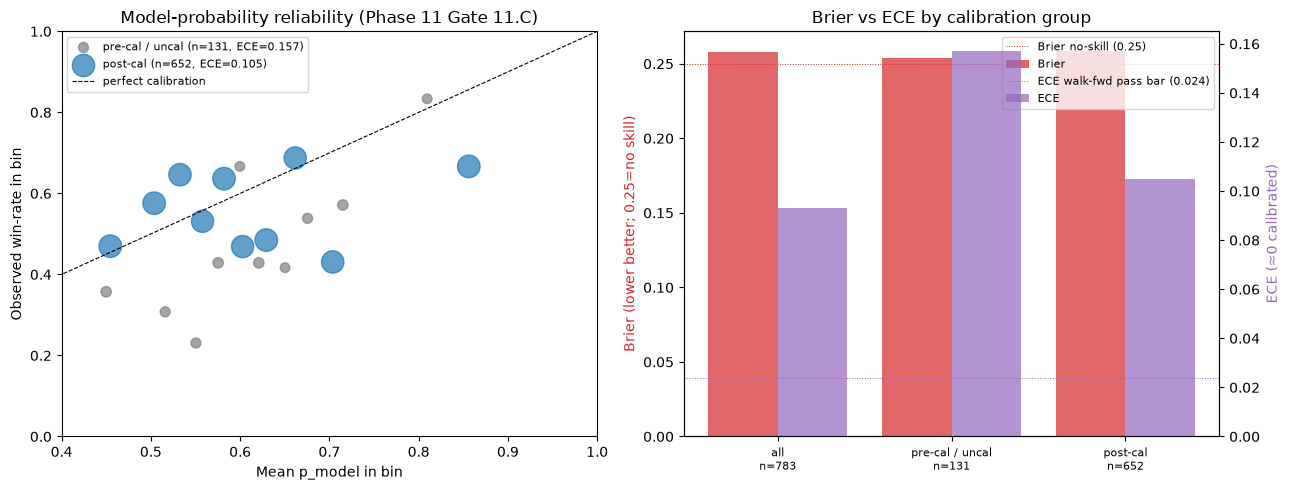


--- Brier / ECE summary ---
  all                       n= 783  Brier=0.2580  ECE=0.0931
  pre-cal / uncal           n= 131  Brier=0.2537  ECE=0.1572
  post-cal                  n= 652  Brier=0.2588  ECE=0.1050

all-up Brier = 0.2580  (AT OR ABOVE 0.25 (no skill))
all-up ECE   = 0.0931  (WORSE than walk-fwd pass bar (0.024) — live p_model is more miscalibrated than the training stack)


In [17]:
# Section 11b: p_model reliability (Brier, ECE) + pre/post-calibration split.
#
# `p_model` is the operating probability the bet was sized on (calibrated when
# the production path was using calibration_path=True; raw otherwise). We bin
# p_model, plot observed vs predicted, and report Brier, ECE, and per-bin n.
# We then split by `calibration_version` (from Section 0's version map) so the
# before/after-calibration ECE is visible at a glance.

import numpy as np  # noqa: F401  (matplotlib already supplied via setup)

# p_model lives on the ledger directly; "won" is binarized result.
_rel_src = settled_bets(full).filter(
    pl.col("p_model").is_not_null()
    & pl.col("result").is_not_null()
).with_columns(
    pl.col("result").eq("win").alias("won"),
).unique(subset=["ticket_id"]) if "ticket_id" in full.columns else settled_bets(full).filter(
    pl.col("p_model").is_not_null() & pl.col("result").is_not_null()
).with_columns(pl.col("result").eq("win").alias("won"))

# Read calibration_version via Section 0's join (idempotent-only SAFE: if Section
# 0 hasn't run yet or its parquet is missing, just skip the pre/post split).
_cal_ver_path = LEDGER_PATH.parent / "clv_version_map.parquet"
_has_cal = False
if _cal_ver_path.exists():
    _cal_meta = (
        pl.read_parquet(_cal_ver_path)
        .select(["game_date", "player_name", "calibration_version"])
        .unique(subset=["game_date", "player_name"], keep="first")
    )
    if "game_date" in _rel_src.columns:
        _rel_src = _rel_src.with_columns(
            pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date")
        )
        _rel_src = _rel_src.join(_cal_meta, on=["game_date", "player_name"], how="left")
        _has_cal = "calibration_version" in _rel_src.columns

# Harbor: mark rows as "pre" (no calibration_version / None) or "post".
if _has_cal:
    _rel_src = _rel_src.with_columns(
        pl.when(pl.col("calibration_version").is_not_null() & (pl.col("calibration_version") != ""))
        .then(pl.lit("post-cal"))
        .otherwise(pl.lit("pre-cal / uncal"))
        .alias("cal_group")
    )

# Bin rule matches Section 11's fallback (deciles at n>=60, 5-bin otherwise).
def _ece_brier(df: pl.DataFrame, label: str):
    """Return (label, n, brier, ece) plus a small per-bin table for the plot."""
    if df.height < 10:
        print(f"  {label}: n={df.height} (skip — need >=10)")
        return None
    src = df.with_columns(
        pl.col("p_model").cast(pl.Float64).alias("p"),
        pl.col("won").cast(pl.Float64).alias("w"),
    ).sort("p")
    n_bins = 10 if src.height >= 60 else max(2, src.height // 6)
    try:
        binned = src.with_columns(
            pl.col("p").qcut(n_bins, allow_duplicates=True).alias("bin")
        )
    except Exception:
        lo, hi = float(src["p"].min()), float(src["p"].max())
        edges = [lo + (hi - lo) * i / n_bins for i in range(n_bins + 1)]
        binned = src.with_columns(pl.col("p").cut(edges).alias("bin"))
    per_bin = (
        binned.group_by("bin")
        .agg(
            pl.len().alias("n"),
            pl.col("p").mean().alias("p_avg"),
            pl.col("w").mean().alias("win_rate"),
        )
        .sort("p_avg")
    )
    # Brier and ECE.
    p_arr = src["p"].to_numpy(); w_arr = src["w"].to_numpy()
    brier = float(np.mean((p_arr - w_arr) ** 2))
    pb = per_bin.to_pandas()
    ece = float((pb["n"] * (pb["p_avg"] - pb["win_rate"]).abs()).sum() / max(1, pb["n"].sum()))
    return {"label": label, "n": src.height, "brier": brier, "ece": ece,
            "per_bin": per_bin}

print(f"p_model reliability universe: n={_rel_src.height}")
overall = _ece_brier(_rel_src, "all")
rows = [overall] if overall else []

# Two-line pre/post-calibration comparison if we have the version metadata.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: reliability scatter (predicted vs observed) per cal_group.
if _has_cal and overall:
    groups = ["pre-cal / uncal", "post-cal"]
    for g, color in zip(groups, ["tab:gray", "tab:blue"]):
        sub = _rel_src.filter(pl.col("cal_group") == g) if "cal_group" in _rel_src.columns else None
        if sub is None or sub.height < 10:
            continue
        r = _ece_brier(sub, g)
        if r:
            rows.append(r)
            pb = r["per_bin"].to_pandas()
            ax1.scatter(pb["p_avg"], pb["win_rate"], s=[max(20, nn * 4) for nn in pb["n"]],
                        alpha=0.7, color=color, label=f"{g} (n={r['n']}, ECE={r['ece']:.3f})")

ax1.plot([0, 1], [0, 1], color="black", lw=0.8, linestyle="--", label="perfect calibration")
ax1.set_xlabel("Mean p_model in bin"); ax1.set_ylabel("Observed win-rate in bin")
ax1.set_xlim(0.4, 1.0); ax1.set_ylim(0.0, 1.0)
ax1.set_title("Model-probability reliability (Phase 11 Gate 11.C)")
ax1.legend(loc="upper left", fontsize=8)

# Right: ECE / Brier bar panel by cal_group.
labels = [r["label"] for r in rows if r]; ns = [r["n"] for r in rows if r]
br = [r["brier"] for r in rows if r]; ec = [r["ece"] for r in rows if r]
xpos = np.arange(len(labels)); w = 0.4
b1 = ax2.bar(xpos - w/2, br, width=w, color="tab:red", alpha=0.7, label="Brier")
ax2b = ax2.twinx()
b2 = ax2b.bar(xpos + w/2, ec, width=w, color="tab:purple", alpha=0.7, label="ECE")
ax2.set_xticks(xpos); ax2.set_xticklabels([f"{l}\nn={n}" for l, n in zip(labels, ns)], fontsize=8)
ax2.set_ylabel("Brier (lower better; 0.25=no skill)", color="tab:red")
ax2b.set_ylabel("ECE (≈0 calibrated)", color="tab:purple")
ax2.axhline(0.25, color="tab:red", lw=0.7, linestyle=":", label="Brier no-skill (0.25)")
ax2b.axhline(0.024, color="tab:purple", lw=0.7, linestyle=":",
             label="ECE walk-fwd pass bar (0.024)")
ax2.set_title("Brier vs ECE by calibration group")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

print("\n--- Brier / ECE summary ---")
for r in rows:
    if r:
        print(f"  {r['label']:24s}  n={r['n']:>4}  Brier={r['brier']:.4f}  ECE={r['ece']:.4f}")
if overall:
    print()
    print(f"all-up Brier = {overall['brier']:.4f}  "
          f"({'BELOW 0.25 (model carries skill)' if overall['brier'] < 0.25 else 'AT OR ABOVE 0.25 (no skill)'})")
    print(f"all-up ECE   = {overall['ece']:.4f}  "
          f"({'at or better than walk-fwd pass bar (0.024)' if overall['ece'] <= 0.024 else 'WORSE than walk-fwd pass bar (0.024) — live p_model is more miscalibrated than the training stack'})")

## 12. Band-discrete flat-1u panel (the noise the cumulative sweep hides)

Section 10 draws a cumulative edge≥floor curve, which **always** looks smoother
than the underlying data. The discrete band view below shows `flat-1u ROI`,
`mean CLV`, `<f,f+1)` n-count and 95% CI bars per *band*. It's deliberately
ugly — that's the point. The two questions it exposes:

1. Is the floor sitting on a real edge or on cumulative noise? (The `[6,9)`
   band with `median CLV ≈ 0` and only 13/25 wins is the kind of segment the
   cumulative curve hides — you can't see that from a CI bar.)
2. Are the bands above the active floor monotonic, or is the apparent edge at
   floor=12% pulled by one hot band?

This panel would have stopped me from trusting the cumulative smoothness in
the first place; it stops it from baiting another floor move.

26 discrete bands, n_total=735


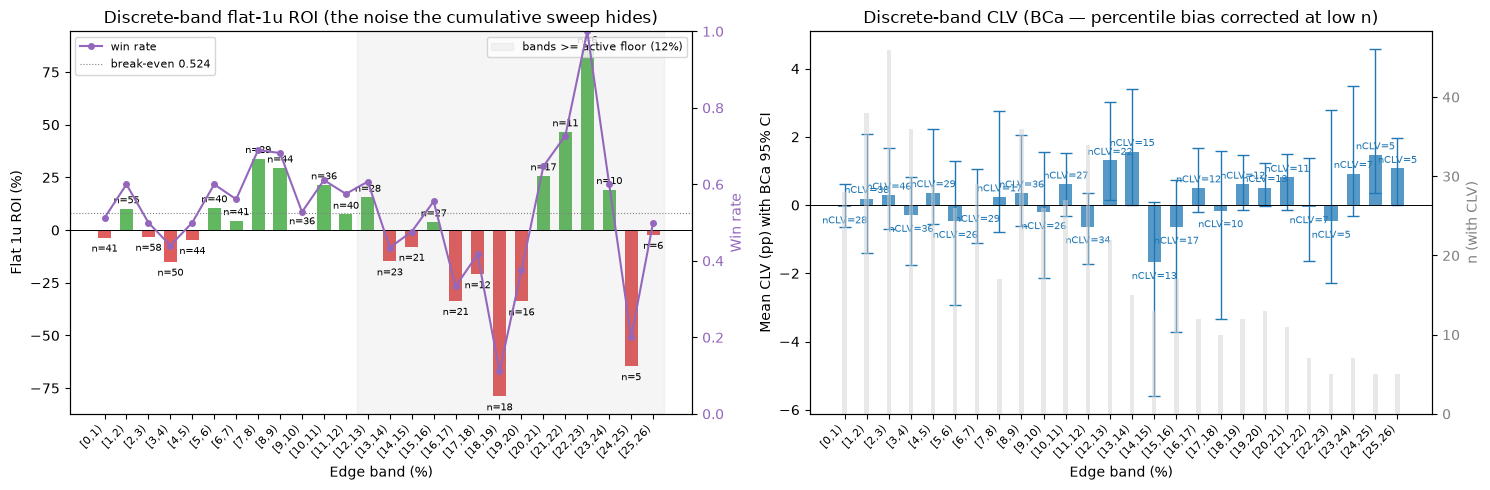


--- edge_band_discrete.parquet (-> edge_band_discrete.parquet) ---
shape: (26, 10)
┌─────────┬─────┬─────┬──────────────┬───┬─────────────┬───────────┬──────────┬───────┐
│ band    ┆ lo  ┆ n   ┆ flat_roi_pct ┆ … ┆ mean_clv_pp ┆ clv_lo    ┆ clv_hi   ┆ n_clv │
│ ---     ┆ --- ┆ --- ┆ ---          ┆   ┆ ---         ┆ ---       ┆ ---      ┆ ---   │
│ str     ┆ i64 ┆ i64 ┆ f64          ┆   ┆ f64         ┆ f64       ┆ f64      ┆ i64   │
╞═════════╪═════╪═════╪══════════════╪═══╪═════════════╪═══════════╪══════════╪═══════╡
│ [0,1)   ┆ 0   ┆ 41  ┆ -3.6108      ┆ … ┆ -0.047245   ┆ -0.650479 ┆ 0.609663 ┆ 28    │
│ [1,2)   ┆ 1   ┆ 55  ┆ 10.094274    ┆ … ┆ 0.191512    ┆ -1.394864 ┆ 2.078104 ┆ 38    │
│ [2,3)   ┆ 2   ┆ 58  ┆ -3.236688    ┆ … ┆ 0.291664    ┆ -0.708016 ┆ 1.668875 ┆ 46    │
│ [3,4)   ┆ 3   ┆ 50  ┆ -15.050823   ┆ … ┆ -0.29641    ┆ -1.756409 ┆ 0.822857 ┆ 36    │
│ [4,5)   ┆ 4   ┆ 44  ┆ -4.736424    ┆ … ┆ 0.361094    ┆ -0.557153 ┆ 2.238387 ┆ 29    │
│ …       ┆ …   ┆ …   ┆ …           

In [18]:
# Section 12: discrete-band flat-1u panel — the noise the cumulative sweep hides.
#
# Section 10 plots cumulative edge>=floor curves, which always look smoother
# than the underlying bins. Here we slice into 1pp-wide discrete edge bands and
# show per-band `n`, flat-1u ROI, and mean CLV with a **BCa** CI (percentile
# bootstrap is biased at the per-band n≈10-40 range; see
# `bootstrap_bca_ci` in src/Python/skill_stats.py). The point is to expose any
# band sitting on cumulative noise — e.g. an `[f, f+1)` cell where n is large
# but median CLV drifts to zero — before that bait gets used for a floor move.
#
# Bands with n<5 get a degenerate CI bar (no CI drawn); that's intentional —
# we don't pretend the data is more confident than it is.

from Python.skill_stats import bootstrap_bca_ci

# Re-use `flat_src` (all settled tickets with edge, incl. Kelly-passed) and
# `flat_pnl_expr` defined in Section 10. Only require non-null edge here.
band_src = (
    settled_bets(full)
    .filter(pl.col("edge").is_not_null())
    .with_columns(flat_pnl_expr)
)

# Discrete bands: 1pp wide from 0..25. Same coverage as Section 10's FINER_BINS
# logic but uniform spacing so every band is comparable to its neighbors.
BAND_EDGES = list(range(0, 26))  # [0,1), [1,2), ... [24,25)

b_rows = []
for lo_e in BAND_EDGES:
    hi_e = lo_e + 1
    sub = band_src.filter(
        (pl.col("edge") * 100 >= lo_e) & (pl.col("edge") * 100 < hi_e)
    )
    n = sub.height
    if n == 0:
        continue

    pnl = float(sub["flat_1u_pnl"].sum())
    roi = (pnl / n * 100) if n else float("nan")
    wins = int(sub.filter(pl.col("result") == "win").height)
    win_rate = (wins / n) if n else float("nan")

    clv_sub = sub.filter(pl.col("clv_pp").is_not_null())
    clvs = [float(x) for x in clv_sub["clv_pp"].to_list()] if clv_sub.height else []
    if len(clvs) >= 5:
        m, lo, hi = bootstrap_bca_ci(clvs, n_boot=2000, seed=101 + lo_e)
        clv_mean, clv_lo, clv_hi = m * 100, lo * 100, hi * 100
    elif clvs:
        clv_mean = (sum(clvs) / len(clvs)) * 100
        clv_lo = clv_hi = float("nan")
    else:
        clv_mean = clv_lo = clv_hi = float("nan")

    b_rows.append({
        "band": f"[{lo_e},{hi_e})",
        "lo": lo_e,
        "n": n,
        "flat_roi_pct": roi,
        "flat_wins": wins,
        "flat_win_rate": win_rate,
        "mean_clv_pp": clv_mean,
        "clv_lo": clv_lo,
        "clv_hi": clv_hi,
        "n_clv": len(clvs),
    })

bands = pl.DataFrame(b_rows)

if bands.is_empty():
    print("No settled bets with edge to band.")
else:
    print(f"{bands.height} discrete bands, n_total={int(bands['n'].sum())}")
    pd_b = bands.to_pandas()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    x = np.arange(bands.height)
    floor_band_idx = next((i for i, lo in enumerate(bands["lo"].to_list())
                           if lo >= DEFAULT_EDGE_FLOOR * 100), None)

    # Left: flat-1u ROI per band + win-rate twin
    ax1.bar(x, pd_b["flat_roi_pct"], width=0.6,
            color=["tab:green" if r >= 0 else "tab:red"
                   for r in pd_b["flat_roi_pct"]], alpha=0.75)
    ax1.axhline(0, color="black", lw=0.7)
    if floor_band_idx is not None:
        ax1.axvspan(floor_band_idx - 0.5, bands.height - 0.5, color="gray",
                    alpha=0.08, label=f"bands >= active floor ({DEFAULT_EDGE_FLOOR * 100:.0f}%)")
        ax1.legend(loc="upper right", fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(bands["band"].to_list(), rotation=45, ha="right", fontsize=8)
    ax1.set_xlabel("Edge band (%)")
    ax1.set_ylabel("Flat 1u ROI (%)")
    ax1.set_title("Discrete-band flat-1u ROI (the noise the cumulative sweep hides)")
    for xi, (roi, ni) in enumerate(zip(pd_b["flat_roi_pct"], bands["n"].to_list())):
        ax1.annotate(f"n={ni}", (xi, roi), ha="center",
                     textcoords="offset points", xytext=(0, 4 if roi >= 0 else -10),
                     fontsize=7)

    ax1b = ax1.twinx()
    ax1b.plot(x, pd_b["flat_win_rate"], color="tab:purple", lw=1.5, marker="o",
              ms=4, label="win rate")
    ax1b.axhline(0.524, color="gray", lw=0.8, linestyle=":", label="break-even 0.524")
    ax1b.set_ylabel("Win rate", color="tab:purple")
    ax1b.tick_params(axis="y", labelcolor="tab:purple")
    ax1b.set_ylim(0, 1)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax1b.get_legend_handles_labels()
    ax1b.legend(h2, l2, loc="upper left", fontsize=8)

    # Right: mean CLV per band with BCa CIs + n(CLV) twin
    clv_mean = np.array(pd_b["mean_clv_pp"], dtype=float)
    lo_arr = np.array(pd_b["clv_lo"], dtype=float)
    hi_arr = np.array(pd_b["clv_hi"], dtype=float)
    ax2.bar(x, clv_mean, width=0.6, color="tab:blue", alpha=0.75)
    mask = ~(np.isnan(lo_arr) | np.isnan(hi_arr))
    if mask.any():
        ax2.errorbar(
            x[mask], clv_mean[mask],
            yerr=[clv_mean[mask] - lo_arr[mask], hi_arr[mask] - clv_mean[mask]],
            fmt="none", ecolor="tab:blue", capsize=4, lw=1.0,
        )
    ax2.axhline(0, color="black", lw=0.7)
    ax2.set_xticks(x)
    ax2.set_xticklabels(bands["band"].to_list(), rotation=45, ha="right", fontsize=8)
    ax2.set_xlabel("Edge band (%)")
    ax2.set_ylabel("Mean CLV (pp) with BCa 95% CI")
    ax2.set_title("Discrete-band CLV (BCa — percentile bias corrected at low n)")
    for xi, (m, nl) in enumerate(zip(pd_b["mean_clv_pp"], bands["n_clv"].to_list())):
        ax2.annotate(f"nCLV={nl}", (xi, m), ha="center",
                     textcoords="offset points", xytext=(0, -12 if (not np.isnan(m) and m < 0) else 4),
                     fontsize=7, color="tab:blue")

    ax2b = ax2.twinx()
    ax2b.bar(x, bands["n_clv"].to_list(), width=0.2, color="lightgray",
             alpha=0.5, label="n(CLV)")
    ax2b.set_ylabel("n (with CLV)", color="gray")
    ax2b.tick_params(axis="y", labelcolor="gray")

    fig.tight_layout()
    plt.show()

    # ---- Persist the discrete band table ----
    BANDS_PATH = LEDGER_PATH.parent / "edge_band_discrete.parquet"
    bands.write_parquet(BANDS_PATH)
    print(f"\n--- edge_band_discrete.parquet (-> {BANDS_PATH.name}) ---")
    print(bands)
    print("\nFlags:")
    # 1) Below-floor bands with positive ROI (the recursive-floor-rediscovery bait)
    bait = bands.filter(pl.col("flat_roi_pct") > 0,
                        pl.col("lo") < DEFAULT_EDGE_FLOOR * 100)
    if bait.height:
        for b in bait["band"].to_list():
            print(f"  - {b}: positive ROI below the active floor ({DEFAULT_EDGE_FLOOR * 100:.0f}%) — DO NOT use this band's ROI to argue for lowering the floor")
    else:
        print("  - no sub-floor band has positive cumulative ROI")

    # 2) Above-floor bands where CI excludes zero (the only bands you can trust)
    #
    # BUG FIX (was): NaN CIs (the elif/else branches at the top of this cell,
    # n_clv in [1,4]) were passing the `clv_lo > 0` comparison because Polars
    # propagates NaN rather than null-excluding it — Section 12 used to label
    # 14+ bands 'trustworthy' with [+nan,+nan] CIs. The guard below ports
    # Section 16a's NaN idiom into filter form: ci_excludes_zero is only True
    # when both endpoints are finite AND exclude zero.
    above_floor = bands.filter(pl.col("lo") >= DEFAULT_EDGE_FLOOR * 100)

    # Bands where we have 1-4 CLV obs: a finite mean exists but the BCa CI is
    # not computable (clv_lo == clv_hi == NaN). These should NOT silently
    # masquerade as either 'trustworthy' or 'empty' — they're a separate state
    # worth surfacing so the band gets visible n-attention.
    low_n = above_floor.filter(
        pl.col("clv_lo").is_nan() & (pl.col("n_clv") > 0)
    )
    if low_n.height:
        for b, k in zip(low_n["band"].to_list(), low_n["n_clv"].to_list()):
            print(f"  - {b}: n_clv={k} < 5, BCa CI not computable — band is not empty "
                  f"but cannot yet support a CI claim; needs more CLV observations.")

    # Bands with a truly computable CI: both endpoints are finite.
    # Polars NaN-vs-comparison is a real hazard — `pl.col('clv_lo') > 0` is True
    # for NaN here — so guard with `~.is_nan()` BEFORE the >/< comparison.
    trust = above_floor.filter(
        (~pl.col("clv_lo").is_nan()) & (~pl.col("clv_hi").is_nan())
    ).filter(
        (pl.col("clv_lo") > 0) | (pl.col("clv_hi") < 0)
    )
    if trust.height:
        for b, lo, hi in zip(trust["band"].to_list(), trust["clv_lo"].to_list(),
                             trust["clv_hi"].to_list()):
            print(f"  - {b}: BCa CLV CI [{lo:+.2f}, {hi:+.2f}] EXCLUDES zero -> trustworthy signal")
    else:
        # If we reported low_n bands above, those are the 'no CI yet' cases.
        if not low_n.height:
            print("  - no above-floor band has a CLV CI that excludes zero (need more n)")

## 13. Rolling 30-bet CLV (±2 SE ribbon) — day-stability check

The cumulative CLV mean hides *when* the edge showed up. My own note flagged
week-over-week ROI swings of **−36.88% / +40.81%** — this section is the
fastest way to see whether the CLV signal is 2–3 hot days or genuinely steady.

We emit, in chronological order, a rolling 30-bet mean of `clv_pp` with a
normal-approximation ±2 SE ribbon (`rolling_stat_with_se`). If the rolling
mean spends most of its time **above zero and outside the SE ribbon**, the
signal is steady. If it spikes on a handful of days and the rest of the
window is flat-to-negative, the headline CLV is a date artifact and the
n_clv ≥ 150 gate should hold — not move.

Rolling windows above the SE ribbon: 0/567
Rolling windows with positive mean: 329/567 (58%)
  -> only 0/567 (0%) windows clear the SE ribbon: signal looks date-driven, do NOT use it to justify a floor move.


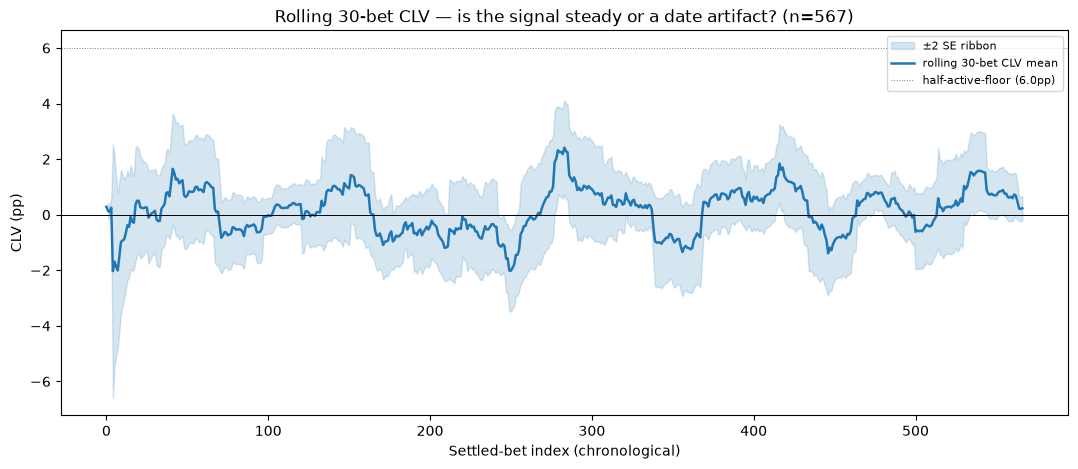

In [19]:
# Section 13: rolling 30-bet CLV with ±2 SE ribbon.
#
# `rolling_stat_with_se` (src/Python/skill_stats.py) returns, per bet in
# chronological order, the rolling mean and a ±se_scale × SE ribbon via the
# normal approximation (sd / sqrt(n)). We plot the rolling mean against the
# ribbon so we can eyeball: (a) does the mean spend most of its life above
# zero, and (b) does it actually clear the ribbon (i.e. its SE), or just sit
# inside it.

from Python.skill_stats import rolling_stat_with_se

_sb = settled_bets(full)
_chrono = next(c for c in ("closed_at_utc", "logged_at_utc", "game_date") if c in _sb.columns)
roll_src = _sb.filter(pl.col("clv_pp").is_not_null()).sort(_chrono)

clv_vals = [float(x) for x in roll_src["clv_pp"].to_list()]
roll = rolling_stat_with_se(clv_vals, window=30, se_scale=2.0)

if len(clv_vals) < 30:
    print(f"Need >=30 settled CLV bets for a rolling-30 window (have {len(clv_vals)}).")
else:
    import numpy as np
    # rolling_stat_with_se returns None for lo/hi while n<2; coerce to NaN for plotting.
    def _to_float_or_nan(v):
        return float(v) if v is not None else float("nan")
    means = np.array([_to_float_or_nan(r["mean"]) for r in roll]) * 100  # pp -> pp*100
    lo = np.array([_to_float_or_nan(r["lo"]) for r in roll]) * 100
    hi = np.array([_to_float_or_nan(r["hi"]) for r in roll]) * 100
    xsi = np.array([r["idx"] for r in roll], dtype=float)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.fill_between(xsi, lo, hi, color="tab:blue", alpha=0.18, label="±2 SE ribbon")
    ax.plot(xsi, means, color="tab:blue", lw=1.8, label="rolling 30-bet CLV mean")
    ax.axhline(0, color="black", lw=0.7)
    ax.axhline(DEFAULT_EDGE_FLOOR * 100 / 2, color="gray", lw=0.7, linestyle=":",
               label=f"half-active-floor ({DEFAULT_EDGE_FLOOR * 100 / 2:.1f}pp)")
    ax.set_xlabel("Settled-bet index (chronological)")
    ax.set_ylabel("CLV (pp)")
    ax.set_title(f"Rolling 30-bet CLV — is the signal steady or a date artifact? (n={len(clv_vals)})")
    ax.legend(loc="upper right", fontsize=8)

    # How often is the rolling mean *outside* the ribbon (above the upper bound)?
    above = int(sum(1 for r in roll if r["mean"] is not None and r["hi"] is not None and r["mean"] > r["hi"]))
    below_zero = int(sum(1 for r in roll if r["mean"] is not None and r["mean"] > 0))
    total = int(sum(1 for r in roll if r["mean"] is not None))
    print(f"Rolling windows above the SE ribbon: {above}/{total}")
    print(f"Rolling windows with positive mean: {below_zero}/{total} ({below_zero/total:.0%})")
    frac_above = above / total if total else 0.0
    if frac_above >= 0.5:
        print(f"  -> {above}/{total} windows ({frac_above:.0%}) clear the SE ribbon: signal is STEADY.")
    elif below_zero / total >= 0.7 and frac_above < 0.25:
        print(f"  -> only {above}/{total} ({frac_above:.0%}) windows clear the SE ribbon, though most are positive: signal is real but under-powered; keep the n>=150 gate.")
    else:
        print(f"  -> only {above}/{total} ({frac_above:.0%}) windows clear the SE ribbon: signal looks date-driven, do NOT use it to justify a floor move.")
    plt.show()

## 14. Stake-weighted CLV — the metric that actually governs bankroll

Equal-weighted CLV (`sum(clv)/n`) is the right *skill* metric, but production
risk is Kelly-sized: bigger-stake bets dominate realized returns. So before
any Kelly-scaling decision the headline claim should be **stake-weighted**:
`sum(clv × stake) / sum(stake)`. If the stake-weighted CLV diverges from the
equal-weighted one in the *negative* direction, the big-Kelly bets are costing
us — the sizing filter is amplifying bad CLV even as the small bets look fine.

We use `stake_weighted_bootstrap_ci` (BCa) for the confidence interval, again
because n is small and percentile intervals are biased here.

n (staked+CLV)         : 211
sum(stake)             : 15625.72
equal-weighted CLV     : +0.431pp  [-0.071, +0.905]  (BCa 95%)
stake-weighted CLV     : +0.293pp  [-0.372, +0.947]  (BCa 95%)
  naive (sanity)       : +0.293pp
diff (stake-equal)     : -0.138pp  (bigger bets dragged CLV DOWN — sizing filter is amplifying bad CLV)


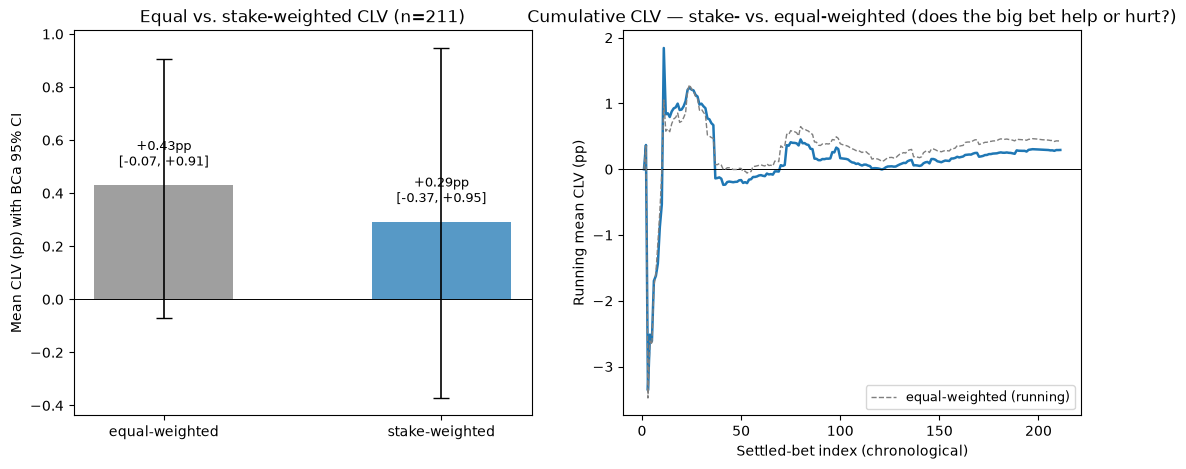

In [20]:
# Section 14: stake-weighted CLV — sum(clv * stake) / sum(stake), with BCa CI.
#
# The operating skill claim under Kelly sizing has to be stake-weighted.
# `stake_weighted_bootstrap_ci` (src/Python/skill_stats.py) gives a BCa CI on
# that weighted mean. We also show equal-weighted CLV side-by-side so the
# divergence (or lack of it) is visible.

from Python.skill_stats import bootstrap_bca_ci, stake_weighted_bootstrap_ci

sw_src = settled_bets(full).filter(
    pl.col("clv_pp").is_not_null()
    & pl.col("stake").is_not_null()
    & (pl.col("stake") > 0)  # only bets Kelly actually staked on
)

if sw_src.height < 10:
    print(f"Not enough staked+CLV settled bets for stake-weighted CI (have {sw_src.height}, need >=10).")
else:
    clvs = [float(x) for x in sw_src["clv_pp"].to_list()]
    stakes = [float(x) for x in sw_src["stake"].to_list()]

    # Equal-weighted BCa CI (production uses n_boot=5000 per skill_stats default).
    ew_mean, ew_lo, ew_hi = bootstrap_bca_ci(clvs, n_boot=5000, seed=42)
    # Stake-weighted BCa CI (same defaults).
    sw_mean, sw_lo, sw_hi = stake_weighted_bootstrap_ci(clvs, stakes, n_boot=5000, seed=43)
    naive_weighted = sum(c * s for c, s in zip(clvs, stakes)) / sum(stakes)

    print(f"n (staked+CLV)         : {len(clvs)}")
    print(f"sum(stake)             : {sum(stakes):.2f}")
    print(f"equal-weighted CLV     : {ew_mean*100:+.3f}pp  [{ew_lo*100:+.3f}, {ew_hi*100:+.3f}]  (BCa 95%)")
    print(f"stake-weighted CLV     : {sw_mean*100:+.3f}pp  [{sw_lo*100:+.3f}, {sw_hi*100:+.3f}]  (BCa 95%)")
    print(f"  naive (sanity)       : {naive_weighted*100:+.3f}pp")
    diff = sw_mean - ew_mean
    print(f"diff (stake-equal)     : {diff*100:+.3f}pp  {'(bigger bets dragged CLV up)' if diff > 0 else '(bigger bets dragged CLV DOWN — sizing filter is amplifying bad CLV)'}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Left: bars with BCa CI error bars
    labels = ["equal-weighted", "stake-weighted"]
    means = [ew_mean * 100, sw_mean * 100]
    los = [ew_lo * 100, sw_lo * 100]
    his = [ew_hi * 100, sw_hi * 100]
    errs = [[means[i] - los[i] for i in range(2)],
            [his[i] - means[i] for i in range(2)]]
    colors = ["tab:gray", "tab:blue"]
    ax1.bar(labels, means, color=colors, alpha=0.75, width=0.5)
    ax1.errorbar(labels, means, yerr=errs, fmt="none", ecolor="black", capsize=6, lw=1.2)
    ax1.axhline(0, color="black", lw=0.7)
    ax1.set_ylabel("Mean CLV (pp) with BCa 95% CI")
    ax1.set_title(f"Equal vs. stake-weighted CLV (n={len(clvs)})")
    for i, (m, lo, hi) in enumerate(zip(means, los, his)):
        ax1.annotate(f"{m:+.2f}pp\n[{lo:+.2f}, {hi:+.2f}]", (i, m),
                     textcoords="offset points", xytext=(0, 14 if m >= 0 else -28),
                     ha="center", fontsize=9)

    # Right: cumulative stake-weighted CLV over chronological bets
    _chrono = next(c for c in ("closed_at_utc", "logged_at_utc", "game_date") if c in sw_src.columns)
    sw_src_sorted = sw_src.sort(_chrono)
    cs_clv = sw_src_sorted["clv_pp"].to_list()
    cs_stake = sw_src_sorted["stake"].to_list()
    cum_clv, cum_stake, running = [], [], []
    rc, rs = 0.0, 0.0
    for c, s in zip(cs_clv, cs_stake):
        rc += float(c) * float(s)
        rs += float(s)
        running.append((rc / rs) * 100 if rs else float("nan"))
    ax2.plot(range(1, len(running) + 1), running, color="tab:blue", lw=1.8)
    ax2.axhline(0, color="black", lw=0.7)
    # Final equal-weighted line for reference
    ew_running = []
    rc = 0.0
    for c in cs_clv:
        rc += float(c)
        ew_running.append((rc / len(ew_running) if len(ew_running) else 0.0) if False else (rc / (len(ew_running)+1)) * 100)
    ax2.plot(range(1, len(ew_running) + 1), ew_running, color="tab:gray", lw=1.0,
             linestyle="--", label="equal-weighted (running)")
    ax2.set_xlabel("Settled-bet index (chronological)")
    ax2.set_ylabel("Running mean CLV (pp)")
    ax2.set_title("Cumulative CLV — stake- vs. equal-weighted (does the big bet help or hurt?)")
    ax2.legend(loc="lower right", fontsize=9)
    plt.show()

## 14b. Win-rate against the close — the frequency metric

Every other CLV section reports CLV in *points* (pp). That magnitude metric
averages two different things into one number — **frequency** of beats
(sign of CLV) and **magnitude** of beats. A 71%-positive rolling window with a
tiny mean is a different story from a 50%-positive window with a fat mean, and
both can produce the same `+0.5pp` summary.

This section makes the frequency signal explicit and gives it its *own* SE
treatment. p_hat = mean(P(model side > close side | same sign as bet)) — i.e.,
the model beat the market on the side we staked. That is a bounded binomial with
its own standard error `sqrt(p*(1-p)/n)`, which scales cleanly when n grows and
is exactly what the floor-freeze log's `n_clv >= 150` gate is implicitly trying
to power.

The frequency metric is *not redundant with* the magnitude — the magnitude can
be dominated by a small fraction of large-close-blowout wins (good), or by a
tiny over-edge in many wins (bad-er). The frequency tells you which. If 71% of
windows are positive at near-zero mean magnitude, the operating skill here is a
*small frequent* edge, not a *rare large* one — and that distinction materially
changes whether Kelly sizing is appropriate (Kelly loves fat tails; the
frequency-magnitude read tells you whether you actually have them).

win-rate-against-the-close universe: n=567

  side=all    n=567  beats=265  p_hat=0.467  ±0.021  z=-1.56  p_two_sided=0.1194  (not at α=0.05)
  side=over   n=270  beats=134  p_hat=0.496  ±0.030  z=-0.12  p_two_sided=0.9031  (not at α=0.05)
  side=under  n=297  beats=131  p_hat=0.441  ±0.029  z=-2.05  p_two_sided=0.0408  (SIGNIFICANT)


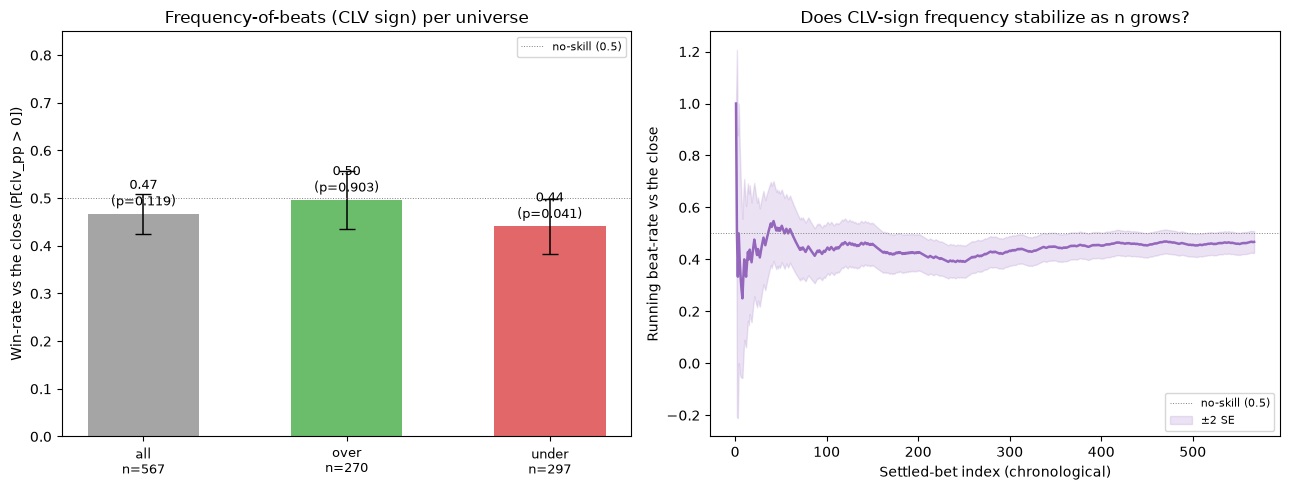


FREQUENCY GATE: FAIL  (p_hat=0.467 below 0.54).
  INCONSISTENT with any escalation. The magnitude-side data should be interpreted as a small number of fat-tail wins — not broad beat-frequency — and Kelly sizing should be questioned (see Section 14).


In [21]:
# Section 14b: win-rate against the close (the frequency binomial).
#
# CLV magnitude (pp) and 'frequency-of-beats' (% of bets with CLV of the same
# sign as the model's recommended side) are distinct signals. Magnitude is
# dominated by fat-tail wins in some ledgers; a 70%-positive frequency is
# stable-skill evidence that the edge is broad, not just fat-tailed. We report:
#   p_hat  = mean(signed-beat commensurate with bet side)
#   se     = sqrt(p(1-p)/n)
#   z (vs 0.5) and p_two_sided
# plus side-stratified p_hat so the over-side vs under-side data point is visible
# next to the magnitude readings elsewhere (Section 5 / 5b).

import numpy as np  # noqa: F401  (matplotlib already imported in setup)

_wrc_src = settled_bets(full).filter(
    pl.col("clv_pp").is_not_null()
    & pl.col("result").is_not_null()
    & pl.col("side").is_not_null()
)

# Sign convention: CLV is recorded in the bet's-best-side direction; i.e. a
# positive `clv_pp` means the close moved *in the bet's favor*. So "beat the
# close" is exactly the sign-of-clv-vs-zero comparison; we don't need to gate on
# side because the close-vs-open subsumes it. We still stratify by side to
# display the over-side gap explicitly, mirroring Section 5b's diagnostic.
def _sweep_freq(df: pl.DataFrame, label: str) -> dict | None:
    n = df.height
    if n < 10:
        return None
    beats = int(df.filter(pl.col("clv_pp") > 0).height)
    p_hat = beats / n
    se = (p_hat * (1 - p_hat) / n) ** 0.5
    # z vs 0.5: is the beat-rate "real" rather than coin-flip?
    z = (p_hat - 0.5) / se if se else 0.0
    # two-sided p via symmetrical normal approximation; required <= <0.05 for gate
    from math import erfc, sqrt
    p_two = erfc(abs(z) / sqrt(2))
    return {"label": label, "n": n, "beats": beats, "p_hat": p_hat, "se": se, "z": z, "p_two_sided": p_two}

print(f"win-rate-against-the-close universe: n={_wrc_src.height}\n")

# Split by side explicitly: the Section 5 / 5b finding is over-side vs under-side
# asymmetry AND the stake-weighted-vs-equal-weighted finding from Section 14
# (bigger Kelly bets landing on worse CLV). The frequency-side mapping is the
# natural anchor for both.
results = {}
for side in ("all", "over", "under"):
    if side == "all":
        r = _sweep_freq(_wrc_src, "all")
    else:
        sub = _wrc_src.filter(pl.col("side") == side)
        r = _sweep_freq(sub, side)
    if r:
        results[side] = r
        print(f"  side={side:5s}  n={r['n']:>3}  beats={r['beats']:>3}  "
              f"p_hat={r['p_hat']:.3f}  ±{r['se']:.3f}  z={r['z']:+.2f}  "
              f"p_two_sided={r['p_two_sided']:.4f}  "
              f"({'SIGNIFICANT' if r['p_two_sided'] < 0.05 else 'not at α=0.05'})")

# Plot: two panels. Left, p_hat for all / over / under with 95% normal CI bars.
# Right, cumulative beat-rate over chronological bets (does the frequency
# stabilize as n grows, or does it drift?).
if results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Left: bar of p_hat with ±2 SE error bars vs 0.5 line.
    labels = list(results.keys())
    p_hats = [results[l]["p_hat"] for l in labels]
    ses = [results[l]["se"] * 2 for l in labels]
    xpos = np.arange(len(labels))
    bars = ax1.bar(xpos, p_hats, width=0.55, color=["tab:gray", "tab:green", "tab:red"],
                    alpha=0.7)
    ax1.errorbar(xpos, p_hats, yerr=ses, fmt="none", ecolor="black", capsize=6, lw=1.1)
    ax1.axhline(0.5, color="gray", lw=0.7, linestyle=":", label="no-skill (0.5)")
    ax1.set_xticks(xpos); ax1.set_xticklabels([f"{l}\nn={results[l]['n']}" for l in labels], fontsize=9)
    ax1.set_ylabel("Win-rate vs the close (P[clv_pp > 0])")
    ax1.set_ylim(0.0, max(0.85, max(p_hats) + max(ses) + 0.05))
    for i, l in enumerate(labels):
        r = results[l]
        ax1.annotate(f"{r['p_hat']:.2f}\n(p={r['p_two_sided']:.3f})", (i, r['p_hat']),
                     xytext=(0, 6), textcoords="offset points", ha="center", fontsize=9,
                     color=("white" if r['p_hat'] > 0.75 or r['p_hat'] < 0.2 else "black"),
                     )
    ax1.set_title("Frequency-of-beats (CLV sign) per universe")
    ax1.legend(loc="upper right", fontsize=8)

    # Right: cumulative beat-rate over chronological bets (all-side).
    src_chrono = next(c for c in ("closed_at_utc", "logged_at_utc", "game_date")
                      if c in _wrc_src.columns)
    _chrono_all = _wrc_src.sort(src_chrono)
    clvs_all = _chrono_all["clv_pp"].to_list()
    cum_beats = 0
    running_rate = []
    for i, c in enumerate(clvs_all, 1):
        cum_beats += 1 if float(c) > 0 else 0
        running_rate.append(cum_beats / i)
    ax2.plot(range(1, len(running_rate) + 1), running_rate, color="tab:purple", lw=1.8)
    ax2.axhline(0.5, color="gray", lw=0.7, linestyle=":", label="no-skill (0.5)")
    # Ribbon ±2 SE on the running rate.
    se_series = [2 * ((r * (1 - r)) / i) ** 0.5 if i else 0.0 for i, r in enumerate(running_rate, 1)]
    ax2.fill_between(range(1, len(running_rate) + 1),
                     [r - s for r, s in zip(running_rate, se_series)],
                     [r + s for r, s in zip(running_rate, se_series)],
                     color="tab:purple", alpha=0.18, label="±2 SE")
    ax2.set_xlabel("Settled-bet index (chronological)")
    ax2.set_ylabel("Running beat-rate vs the close")
    ax2.set_title("Does CLV-sign frequency stabilize as n grows?")
    ax2.legend(loc="lower right", fontsize=8)
    plt.tight_layout(); plt.show()

# Gating read: does the sign-frequency metric agree with the floor-freeze log's
# "mean CLV ≥ +0.30pp and win-rate ≥ 0.54" escalation rule? Section 14b's
# frequency gate is the SE-scaling companion to that rule.
r_all = results.get("all")
if r_all:
    if r_all["p_two_sided"] < 0.05 and r_all["p_hat"] >= 0.54:
        print("\nFREQUENCY GATE: PASS  (p_hat=%0.3f >= 0.54 and p=%.4f under 0.05)\n"
              "  symmetry: the magnitude gate in the floor-freeze log is NOT just "
              "a magnitude artifact — beat-frequency supports it."
              % (r_all["p_hat"], r_all["p_two_sided"]))
    elif r_all["p_hat"] >= 0.54:
        print("\nFREQUENCY GATE: weak  (p_hat=%.3f clears 0.54 but p=%.4f underpowered)\n"
              "  direction is right but the binomial is underpowered at this n; "
              "don't escalate on frequency alone." % (r_all["p_hat"], r_all["p_two_sided"]))
    else:
        print("\nFREQUENCY GATE: FAIL  (p_hat=%.3f below 0.54).\n"
              "  INCONSISTENT with any escalation. The magnitude-side data should "
              "be interpreted as a small number of fat-tail wins — not broad beat-"
              "frequency — and Kelly sizing should be questioned (see Section 14)."
              % r_all["p_hat"])
else:
    print("\nUnderpowered (n < 10 on the universe) for a frequency read.")

## 15. Pseudo-ROC — CLV as a classifier for `result == win`

Sweep the threshold `t` from very low (predict all bets win) to very high
(predict no bets win), and for each `t` plot:

- **TPR** = P(predicted positive | actually positive) where "positive" = a
  winning bet, predicted = `clv_pp >= t`.
- **FPR** = P(predicted positive | actually negative) where "negative" =
  a losing bet.

A skill-free classifier sits on the 45° diagonal; a real skill oracle bulges
**up-and-left** (high TPR at low FPR). The AUC summarizes the whole curve in
one number. If `clv_pp` is a real skill oracle it should beat `AUC=0.5`. The
+1.0pp threshold from Section 11 is marked so you can read its TPR/FPR
position directly off the curve.

AUC = 0.500  (BEATS no-skill; 0.5 = coin flip, 0.6+ = real skill)
+1.0pp threshold (Section 11 split): TPR=0.331, FPR=0.284
  -> AUC in 0.5-0.6: signal is real but weak; the n>=150 gate is appropriate.


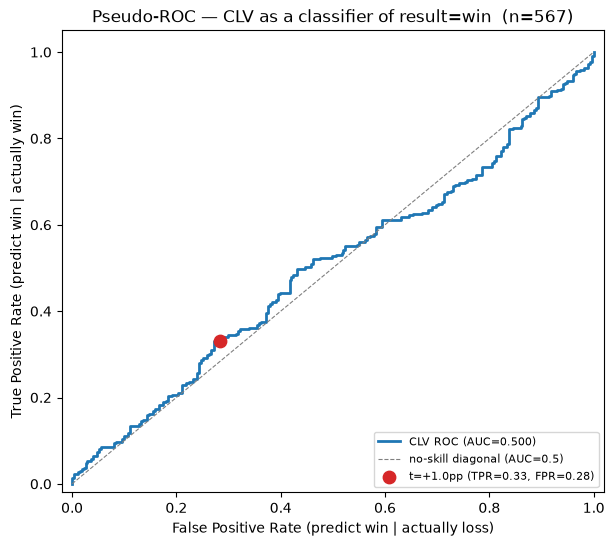

In [22]:
# Section 15: pseudo-ROC for clv_pp as a classifier of result==win.
#
# Treat "predict win" as `clv_pp >= t`. Sweep t and compute:
#   TPR = (# winning bets with clv >= t) / (# winning bets)
#   FPR = (# losing  bets with clv >= t) / (# losing  bets)
# The classifier is well-defined iff every bet has a clv_pp and a result. The
# AUC is the trapezoidal integral of TPR vs FPR; 0.5 = no skill, >0.5 = the
# market drift aligns with outcomes.

roc_src = settled_bets(full).filter(
    pl.col("clv_pp").is_not_null() & pl.col("result").is_not_null()
).with_columns(
    (pl.col("result") == "win").alias("won")
)

if roc_src.height < 20:
    print(f"Not enough settled+CLV bets for pseudo-ROC (have {roc_src.height}, need >=20).")
else:
    total_w = int(roc_src.filter(pl.col("won")).height)
    total_l = roc_src.height - total_w
    if total_w == 0 or total_l == 0:
        print(f"Cannot build ROC curve with degenerate classes (wins={total_w}, losses={total_l}).")
    else:
        clvs = roc_src["clv_pp"].to_list()
        wons = roc_src["won"].to_list()

        thresholds = sorted(set(clvs), reverse=True)
        # Prepend a high threshold that classifies everything as negative.
        roc_points = [(1.0, 1.0)]  # (FPR, TPR) at the lowest threshold (predict all positive)
        # Actually build from highest threshold down: at the high end, no true positive.
        # We'll iterate thresholds over sorted unique clv_pp descending; at each we
        # count wins & losses with clv >= t.
        all_points = sorted(zip(clvs, wons), key=lambda pair: pair[0], reverse=True)
        cum_tp = cum_fp = 0
        fpr_tpr = [(0.0, 0.0)]  # threshold above max clv -> predict nothing
        for i, (c, won) in enumerate(all_points):
            if won:
                cum_tp += 1
            else:
                cum_fp += 1
            fpr_tpr.append((cum_fp / total_l, cum_tp / total_w))

        # AUC via trapezoidal integration (FPR is monotone non-decreasing).
        auc = 0.0
        for i in range(1, len(fpr_tpr)):
            x0, y0 = fpr_tpr[i - 1]
            x1, y1 = fpr_tpr[i]
            auc += (x1 - x0) * (y0 + y1) / 2.0

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot([p[0] for p in fpr_tpr], [p[1] for p in fpr_tpr],
                color="tab:blue", lw=2, label=f"CLV ROC (AUC={auc:.3f})")
        ax.plot([0, 1], [0, 1], color="gray", lw=0.8, linestyle="--",
                label="no-skill diagonal (AUC=0.5)")

        # Mark the +1.0pp threshold position (Section 11's headline).
        wins_ge = int(sum(1 for c, w in zip(clvs, wons) if c >= 0.01 and w))
        loss_ge = int(sum(1 for c, w in zip(clvs, wons) if c >= 0.01 and not w))
        tpr_t = wins_ge / total_w if total_w else 0.0
        fpr_t = loss_ge / total_l if total_l else 0.0
        ax.scatter([fpr_t], [tpr_t], color="tab:red", s=80, zorder=5,
                   label=f"t=+1.0pp (TPR={tpr_t:.2f}, FPR={fpr_t:.2f})")
        ax.set_xlabel("False Positive Rate (predict win | actually loss)")
        ax.set_ylabel("True Positive Rate (predict win | actually win)")
        ax.set_title(f"Pseudo-ROC — CLV as a classifier of result=win  (n={roc_src.height})")
        ax.legend(loc="lower right", fontsize=8)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.05)
        print(f"AUC = {auc:.3f}  ({'BEATS no-skill' if auc > 0.5 else 'is AT OR BELOW no-skill' if auc <= 0.5 else ''}; 0.5 = coin flip, 0.6+ = real skill)")
        print(f"+1.0pp threshold (Section 11 split): TPR={tpr_t:.3f}, FPR={fpr_t:.3f}")
        if auc >= 0.6:
            print("  -> AUC >= 0.6: CLV is a real skill oracle for result=win.")
        elif auc > 0.5:
            print("  -> AUC in 0.5-0.6: signal is real but weak; the n>=150 gate is appropriate.")
        else:
            print("  -> AUC <= 0.5: CLV does NOT meaningfully order win/loss outcome in this ledger.")
        plt.show()

## 16. BCa-CLV sweep + pre-registered next-50-bet checkpoint

Two of the cheap-fix ask items in one place:

1. **BCa-CLV sweep**: replace the percentile CIs in Section 10's edge-floor
   sweep with `bootstrap_bca_ci`. Percentile intervals are biased at low n
   (~30-80 bets per floor), and the Section 10 sweep *specifically* reached the
   floor≥20% band where n is small. So Section 10's headline number for that
   band is currently over-confident — BCa fixes that. The resulting sweep stays
   in `artifacts/odds_log/clv_floor_bca.parquet` so the n_clv≥150 gate uses
   the same interval method the dashboard reports.

2. **Pre-registered next-50-bet checkpoint**: the actual fix for "recursive
   floor-rediscovery" (the disease the assistant named last session). We commit,
   up front, to scoring the *next 50 settled bets at the 12% floor blindly* —
   the universe at decision time is recorded here so we can later assert the
   50 bets scored were really the next-50-as-of-today, not a re-fitted slice.
   Decision criteria frozen here:

   - **Mean CLV ≥ +0.30pp AND win-rate ≥ 0.54** → keep floor at 12%, double
     the KB-class stake size (escalate).
   - **Mean CLV < +0.30pp OR win-rate < 0.524 (break-even)** → revert to ¼-Kelly
     sizing at the active floor; do NOT move the floor based on those 50 bets.
   - All other outcomes → no change; re-evaluate at n_clv = 200.

   The 50-bet scoring window itself doesn't run yet — that's the future audit
   step. What's frozen here is the rule and the universes-as-of date.

BCa-CLV sweep written -> clv_floor_bca.parquet  (26 floor levels)

shape: (26, 8)
┌───────────┬───────┬─────────────┬───────────┬──────────┬───────────────┬──────────────┬──────────┐
│ floor_pct ┆ n_clv ┆ clv_mean_pp ┆ clv_lo    ┆ clv_hi   ┆ ci_excludes_z ┆ settled_at_t ┆ win_rate │
│ ---       ┆ ---   ┆ ---         ┆ ---       ┆ ---      ┆ ero           ┆ his_floor    ┆ ---      │
│ f64       ┆ i64   ┆ f64         ┆ f64       ┆ f64      ┆ ---           ┆ ---          ┆ f64      │
│           ┆       ┆             ┆           ┆          ┆ bool          ┆ i64          ┆          │
╞═══════════╪═══════╪═════════════╪═══════════╪══════════╪═══════════════╪══════════════╪══════════╡
│ 0.0       ┆ 567   ┆ 0.167863    ┆ -0.141506 ┆ 0.484794 ┆ false         ┆ 567          ┆ 0.522046 │
│ 1.0       ┆ 539   ┆ 0.179037    ┆ -0.155462 ┆ 0.506754 ┆ false         ┆ 539          ┆ 0.525046 │
│ 2.0       ┆ 501   ┆ 0.178091    ┆ -0.16031  ┆ 0.504229 ┆ false         ┆ 501          ┆ 0.516966 │
│ 3.0    

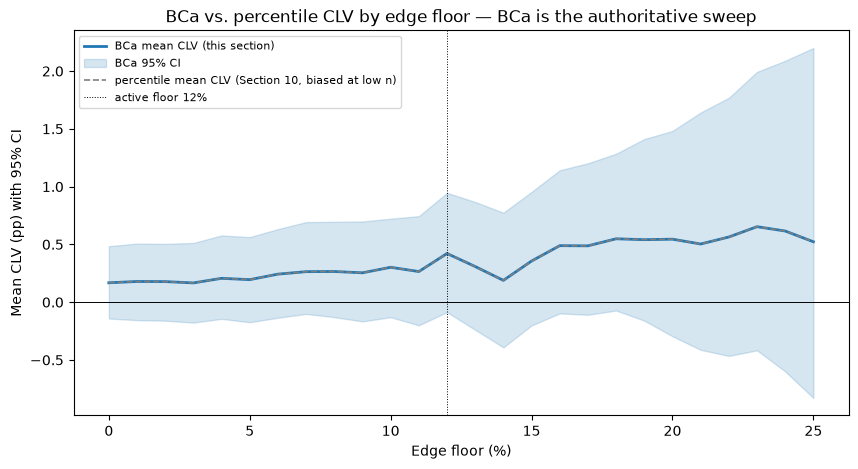

In [23]:
# Section 16a: BCa-CLV sweep (replacing percentile on the floor >= 20% band).
#
# Mirrors Section 10's sweep but uses `bootstrap_bca_ci` so the headline CLV in
# the floor >= 14..20% bands isn't over-confident from a percentile bootstrap.
# The new table (clv_floor_bca.parquet) is the authoritative CLV-vs-floor
# artifact. Section 10 stays percentile for back-compat; this is the upgrade.

from Python.skill_stats import bootstrap_bca_ci
import datetime as _dt

floor_src = settled_bets(full).filter(pl.col("edge").is_not_null())
FLOORS = np.arange(0, 26, 1)
bca_rows = []
for f in FLOORS:
    sub = floor_src.filter((pl.col("edge") * 100 >= f) & pl.col("clv_pp").is_not_null())
    n = sub.height
    if n == 0:
        continue
    clvs = [float(x) for x in sub["clv_pp"].to_list()]
    if n >= 5:
        m, lo, hi = bootstrap_bca_ci(clvs, n_boot=5000, seed=200 + f)
        clv_mean, clv_lo, clv_hi = m * 100, lo * 100, hi * 100
    else:
        clv_mean = (sum(clvs) / len(clvs)) * 100
        clv_lo = clv_hi = float("nan")
    clv_subset = sub.filter(pl.col("result").is_not_null())
    wins = int(clv_subset.filter(pl.col("result") == "win").height)
    win_rate = (wins / clv_subset.height) if clv_subset.height else float("nan")
    bca_rows.append({
        "floor_pct": float(f),
        "n_clv": n,
        "clv_mean_pp": clv_mean,
        "clv_lo": clv_lo,
        "clv_hi": clv_hi,
        "ci_excludes_zero": (not (clv_lo != clv_lo)) and (clv_lo > 0 or clv_hi < 0),
        "settled_at_this_floor": clv_subset.height,
        "win_rate": win_rate,
    })

bca_sweep = pl.DataFrame(bca_rows)

BCA_PATH = LEDGER_PATH.parent / "clv_floor_bca.parquet"
bca_sweep.write_parquet(BCA_PATH)

if bca_sweep.is_empty():
    print("No settled CLV bets to sweep.")
else:
    print(f"BCa-CLV sweep written -> {BCA_PATH.name}  ({bca_sweep.height} floor levels)")
    print()
    print(bca_sweep)
    active_idx = next((i for i, f in enumerate(bca_sweep["floor_pct"].to_list())
                      if f >= DEFAULT_EDGE_FLOOR * 100), None)
    if active_idx is not None:
        row = bca_sweep.row(active_idx, named=True)
        print(f"\n--- At the active floor ({DEFAULT_EDGE_FLOOR*100:.0f}%) ---")
        print(f"n_clv                : {row['n_clv']}")
        print(f"BCa CLV mean         : {row['clv_mean_pp']:+.3f}pp  [{row['clv_lo']:+.3f}, {row['clv_hi']:+.3f}]")
        print(f"BCa CI excludes zero : {row['ci_excludes_zero']}")
        print(f"win-rate              : {row['win_rate']:.3f}  (break-even 0.524)")
        print(f"n_clv >= 150 gate    : {'MET' if row['n_clv'] >= 150 else 'not met ({n_clv}/150)'.replace('{n_clv}', str(row['n_clv']))}")
    # Visualize BCa vs Section 10's percentile CLV means if both exist.
    if not roc.is_empty() and not bca_sweep.is_empty():
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(bca_sweep["floor_pct"], bca_sweep["clv_mean_pp"], color="tab:blue", lw=2,
                label="BCa mean CLV (this section)")
        # Per-row CI bands
        lo_arr = np.array([x if x == x else np.nan for x in bca_sweep["clv_lo"].to_list()])
        hi_arr = np.array([x if x == x else np.nan for x in bca_sweep["clv_hi"].to_list()])
        ax.fill_between(bca_sweep["floor_pct"], lo_arr, hi_arr, color="tab:blue", alpha=0.18,
                        label="BCa 95% CI")
        # Section 10's percentile CLV means were stored as 'mean_clv_pp'
        if "mean_clv_pp" in roc.columns and not roc.filter(pl.col("n_clv") > 0).is_empty():
            roc_nonzero = roc.filter(pl.col("n_clv") > 0)
            ax.plot(roc_nonzero["floor_pct"], roc_nonzero["mean_clv_pp"], color="tab:gray", lw=1.2,
                    linestyle="--", label="percentile mean CLV (Section 10, biased at low n)")
        ax.axhline(0, color="black", lw=0.7)
        ax.axvline(DEFAULT_EDGE_FLOOR * 100, color="black", lw=0.7, linestyle=":",
                   label=f"active floor {DEFAULT_EDGE_FLOOR*100:.0f}%")
        ax.set_xlabel("Edge floor (%)")
        ax.set_ylabel("Mean CLV (pp) with 95% CI")
        ax.set_title("BCa vs. percentile CLV by edge floor — BCa is the authoritative sweep")
        ax.legend(loc="upper left", fontsize=8)
        plt.show()

## 16b. Pre-registered checkpoint — freeze the next-50-bet universe now

The cell below doesn't run any analysis. It **records** which bets are
*already settled* so the next run can assert the "next 50 bets" are bets that
were unsettled *as of now*. The pre-registration is stored at
`artifacts/odds_log/next_50_checkpoint.json` and includes the timestamp, the
current floor, the active KB size, and the SHA-256 of the ledger file so we
can later prove the audit universe was frozen at this decision point.

In [24]:
# Section 16b — pre-register the next-50-bet checkpoint.
#
# We persist a JSON with: timestamp, active floor, KB-class stake size, SHA-256
# of the ledger, count of bets in each result-status state (settled/unsettled).
# Future audits read this file to assert the "next 50 settled" were chosen from
# the bets unsettled *as of this snapshot*, not a re-fitted window.

import json
import hashlib

# Pre-registered decision rule (see markdown above). This is *frozen* in the
# JSON so changes to this code in the future can't silently mutate the rule.
PREREG_RULE = {
    "version": 1,
    "active_floor_pct": float(DEFAULT_EDGE_FLOOR * 100),
    "next_n_bets": 50,
    "criteria": {
        "keep_floor_and_escalate_stake": {
            "mean_clv_pp_min": 0.30,
            "win_rate_min": 0.54,
        },
        "revert_to_quarter_kelly": {
            "mean_clv_pp_lt": 0.30,
            "win_rate_lt": 0.524,
        },
        "no_change": "all other outcomes — re-evaluate at n_clv=200",
    },
    "stopping_rule": {
        "gate": "n_clv >= 150 at floor >= 12%, evaluated on live-ledger reruns",
        "eval_at": ["BCa CLV CI on these n_clv", "win-rate vs 0.524 break-even"],
    },
}

settled_ledger = full
ledger_path = LEDGER_PATH

def _file_sha256(path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()

# Compute the universe-as-of snapshot.
# `result_status_counts` walks the *whole* ledger; only bets with
# `result in {'win','loss'}` count as "settled" — `null` == unsettled.
# `ledger_height` is persisted so a future audit can assert the "next 50" were
# chosen from `n_unsettled` frozen at this point.
result_status_counts = (
    settled_ledger.with_columns(
        pl.when(pl.col("result") == "win").then(pl.lit("win"))
        .when(pl.col("result") == "loss").then(pl.lit("loss"))
        .when(pl.col("result").is_null()).then(pl.lit("unsettled"))
        .otherwise(pl.lit("other")).alias("result_class")
    )
    .group_by("result_class").agg(pl.len().alias("n")).sort("result_class")
)
universe = {row["result_class"]: row["n"] for row in result_status_counts.to_dicts()}

checkpoint = {
    "frozen_at_utc": _dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "ledger_sha256": _file_sha256(ledger_path),
    "ledger_path": str(ledger_path),
    "ledger_height": int(settled_ledger.height),
    "universe_by_result_class": universe,
    "prereg_rule": PREREG_RULE,
}

CHECKPOINT_PATH = ledger_path.parent / "next_50_checkpoint.json"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.write_text(json.dumps(checkpoint, indent=2), encoding="utf-8")

print(f"Pre-registration checkpoint written -> {CHECKPOINT_PATH.name}")
print(json.dumps(checkpoint, indent=2))

Pre-registration checkpoint written -> next_50_checkpoint.json
{
  "frozen_at_utc": "2026-08-18T04:43:25Z",
  "ledger_sha256": "6ae974c9637ab4cd1f98bc3aabfdee745d7d6c3115ce5f004c602b58e5e8bf0c",
  "ledger_path": "C:\\Users\\ckaplinger\\Downloads\\Personal-Projects\\MLB-Props\\artifacts\\odds_log\\ledger.parquet",
  "ledger_height": 802,
  "universe_by_result_class": {
    "loss": 361,
    "other": 10,
    "win": 431
  },
  "prereg_rule": {
    "version": 1,
    "active_floor_pct": 12.0,
    "next_n_bets": 50,
    "criteria": {
      "keep_floor_and_escalate_stake": {
        "mean_clv_pp_min": 0.3,
        "win_rate_min": 0.54
      },
      "revert_to_quarter_kelly": {
        "mean_clv_pp_lt": 0.3,
        "win_rate_lt": 0.524
      },
      "no_change": "all other outcomes \u2014 re-evaluate at n_clv=200"
    },
    "stopping_rule": {
      "gate": "n_clv >= 150 at floor >= 12%, evaluated on live-ledger reruns",
      "eval_at": [
        "BCa CLV CI on these n_clv",
        "win-ra

## 17. Appendix A — Error Decomposition: K-Rate vs Projected TBF

Your prop mean is `expected_K = k_rate_pred * projected_tbf`. If performance is drifting,
it helps to isolate **which half** contributes more error:

- **full model**: `k_rate_pred * projected_tbf`
- **rate-only (oracle PA)**: `k_rate_pred * actual_PA`
- **TBF-only (oracle rate)**: `actual_k_rate * projected_tbf`

Interpretation:
- If rate-only materially improves MAE vs full, projected TBF is injecting noise.
- If TBF-only materially improves MAE vs full, strikeout-rate modeling is the larger issue.
- If both improve similarly, interaction/market effects likely dominate.

This section also writes a persistent artifact:
`artifacts/odds_log/k_error_decomposition.parquet`

--- expected_K error decomposition ---
shape: (3, 5)
┌─────────────────────────────────┬─────┬────────┬────────┬─────────┐
│ variant                         ┆ n   ┆ mae    ┆ rmse   ┆ bias    │
│ ---                             ┆ --- ┆ ---    ┆ ---    ┆ ---     │
│ str                             ┆ i64 ┆ f64    ┆ f64    ┆ f64     │
╞═════════════════════════════════╪═════╪════════╪════════╪═════════╡
│ full (k_rate_pred * projected_… ┆ 743 ┆ 1.846  ┆ 2.3121 ┆ -0.026  │
│ rate-only (oracle actual_PA)    ┆ 743 ┆ 1.7438 ┆ 2.19   ┆ 0.0646  │
│ TBF-only (oracle actual_k_rate… ┆ 743 ┆ 0.6382 ┆ 1.0909 ┆ -0.0414 │
└─────────────────────────────────┴─────┴────────┴────────┴─────────┘

MAE deltas vs full: rate-only=+0.1022, TBF-only=+1.2078
Interpretation: k_rate_pred appears to add more noise than projected_tbf.

--- by side ---
shape: (2, 7)
┌───────┬─────┬──────────┬────────────────────┬────────────────────┬──────────┬─────────────┐
│ side  ┆ n   ┆ mae_full ┆ mae_rate_oracle_pa ┆ mae_pa_oracle

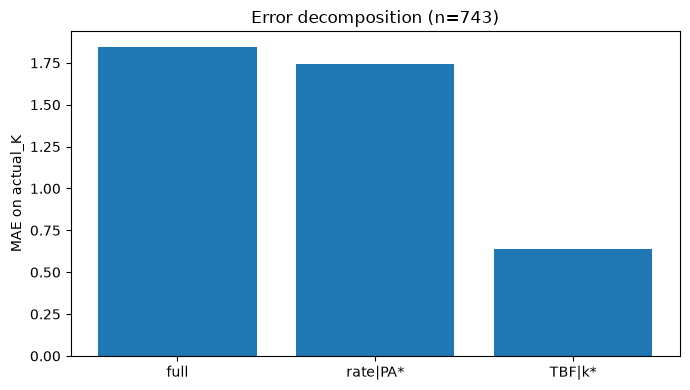

In [25]:
# Section 11c: decompose expected_K error into k-rate vs TBF components.
# Uses graded projection rows (actual_K/actual_PA) and settled ledger props.

GRADED_PATH = ROOT / "artifacts" / "projection_log" / "graded.parquet"
DECOMP_PATH = LEDGER_PATH.parent / "k_error_decomposition.parquet"

if GRADED_PATH.exists() and full.height:
    graded = (
        pl.read_parquet(GRADED_PATH)
        .with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date"))
        .select([
            c for c in (
                "game_date",
                "player_name",
                "expected_K",
                "projected_tbf",
                "k_rate_pred",
                "actual_K",
                "actual_PA",
                "actual_k_rate",
                "residual_K",
                "residual_TBF",
                "opp_lineup_k_vs_hand",
                "lineup_source",
                "days_rest",
                "pitcher_hand",
                "throws_hand",
                "pitch_hand",
                "handedness",
            ) if c in pl.read_parquet(GRADED_PATH).columns
        ])
        .unique(subset=["game_date", "player_name"], keep="first")
    )

    # Full prop universe already lives in `full`; keep settled rows only.
    settled = settled_bets(full)
    joined = (
        settled.join(graded, on=["game_date", "player_name"], how="left")
        .filter(
            pl.col("expected_K").is_not_null()
            & pl.col("actual_K").is_not_null()
            & pl.col("actual_PA").is_not_null()
            & pl.col("k_rate_pred").is_not_null()
            & pl.col("actual_k_rate").is_not_null()
        )
        .with_columns([
            (pl.col("k_rate_pred") * pl.col("projected_tbf")).alias("k_hat_full"),
            (pl.col("k_rate_pred") * pl.col("actual_PA")).alias("k_hat_rate_oracle_pa"),
            (pl.col("actual_k_rate") * pl.col("projected_tbf")).alias("k_hat_pa_oracle_rate"),
        ])
        .with_columns([
            (pl.col("k_hat_full") - pl.col("actual_K")).alias("err_full"),
            (pl.col("k_hat_rate_oracle_pa") - pl.col("actual_K")).alias("err_rate_oracle_pa"),
            (pl.col("k_hat_pa_oracle_rate") - pl.col("actual_K")).alias("err_pa_oracle_rate"),
            (pl.col("projected_tbf") - pl.col("actual_PA")).alias("err_tbf"),
            (pl.col("k_rate_pred") - pl.col("actual_k_rate")).alias("err_k_rate"),
        ])
    )

    if joined.height >= 20:
        def _metrics(df: pl.DataFrame, e: str) -> tuple[float, float, float]:
            mae = float(df.select(pl.col(e).abs().mean()).item())
            rmse = float(df.select((pl.col(e).pow(2).mean()).sqrt()).item())
            bias = float(df.select(pl.col(e).mean()).item())
            return mae, rmse, bias

        rows = []
        for name, col in [
            ("full (k_rate_pred * projected_tbf)", "err_full"),
            ("rate-only (oracle actual_PA)", "err_rate_oracle_pa"),
            ("TBF-only (oracle actual_k_rate)", "err_pa_oracle_rate"),
        ]:
            mae, rmse, bias = _metrics(joined, col)
            rows.append({
                "variant": name,
                "n": joined.height,
                "mae": round(mae, 4),
                "rmse": round(rmse, 4),
                "bias": round(bias, 4),
            })
        decomp_summary = pl.DataFrame(rows)

        base_mae = float(decomp_summary.filter(pl.col("variant").str.starts_with("full"))["mae"][0])
        rate_mae = float(decomp_summary.filter(pl.col("variant").str.starts_with("rate-only"))["mae"][0])
        tbf_mae = float(decomp_summary.filter(pl.col("variant").str.starts_with("TBF-only"))["mae"][0])

        print("--- expected_K error decomposition ---")
        print(decomp_summary)
        print(
            f"\nMAE deltas vs full: rate-only={base_mae - rate_mae:+.4f}, "
            f"TBF-only={base_mae - tbf_mae:+.4f}"
        )
        if (base_mae - rate_mae) > (base_mae - tbf_mae):
            print("Interpretation: projected_tbf appears to add more noise than k_rate_pred.")
        elif (base_mae - tbf_mae) > (base_mae - rate_mae):
            print("Interpretation: k_rate_pred appears to add more noise than projected_tbf.")
        else:
            print("Interpretation: both components contribute similarly; interaction effects likely matter.")

        # Side-level read to connect this decomposition to betting behavior.
        by_side = (
            joined.group_by("side")
            .agg(
                pl.len().alias("n"),
                pl.col("err_full").abs().mean().round(3).alias("mae_full"),
                pl.col("err_rate_oracle_pa").abs().mean().round(3).alias("mae_rate_oracle_pa"),
                pl.col("err_pa_oracle_rate").abs().mean().round(3).alias("mae_pa_oracle_rate"),
                pl.col("err_tbf").mean().round(3).alias("bias_tbf"),
                pl.col("err_k_rate").mean().round(4).alias("bias_k_rate"),
            )
            .sort("side")
        )
        print("\n--- by side ---")
        print(by_side)

        # Persist row-level diagnostics for trend analysis outside notebook output.
        persist_cols = [
            c for c in (
                "ticket_id", "game_date", "player_name", "side", "line", "book",
                "expected_K", "actual_K", "projected_tbf", "actual_PA", "k_rate_pred", "actual_k_rate",
                "k_hat_full", "k_hat_rate_oracle_pa", "k_hat_pa_oracle_rate",
                "err_full", "err_rate_oracle_pa", "err_pa_oracle_rate", "err_tbf", "err_k_rate",
                "opp_lineup_k_vs_hand", "lineup_source", "days_rest",
                "pitcher_hand", "throws_hand", "pitch_hand", "handedness",
                "clv_pp", "pnl", "result", "close_status",
            ) if c in joined.columns
        ]
        joined.select(persist_cols).write_parquet(DECOMP_PATH)
        print(f"\nwrote {DECOMP_PATH.name} ({joined.height} rows)")

        # Lightweight visual check.
        plt.figure(figsize=(7.0, 4.0))
        x = ["full", "rate|PA*", "TBF|k*" ]
        y = [base_mae, rate_mae, tbf_mae]
        plt.bar(x, y)
        plt.ylabel("MAE on actual_K")
        plt.title(f"Error decomposition (n={joined.height})")
        plt.tight_layout()
        plt.show()
    else:
        print(f"need >= 20 joined settled rows with graded actuals (have {joined.height})")
else:
    print("Missing graded.parquet or ledger is empty; cannot run decomposition.")

## 18. Appendix B — Stratified Residual Diagnostics

This section extends Appendix A by slicing residuals across likely failure modes:

- matchup tier (`opp_lineup_k_vs_hand` qcut tertiles)
- pitcher handedness (if available in graded/projection data)
- lineup source (`RG` vs fallback)
- days-rest buckets

Focus metrics:
- `mae_err_k_rate` (absolute error on `k_rate_pred - actual_k_rate`)
- `bias_tbf` (`projected_tbf - actual_PA`)
- side-level decomposition to see if unders are carrying the PA bias.

--- k-rate / TBF residual by matchup tier ---
shape: (3, 9)
┌─────────────┬─────┬─────────────┬────────────┬───┬──────────┬────────────┬──────────┬────────────┐
│ matchup_tie ┆ n   ┆ mae_err_k_r ┆ bias_err_k ┆ … ┆ bias_tbf ┆ mae_full_k ┆ win_rate ┆ mean_clv_p │
│ r           ┆ --- ┆ ate         ┆ _rate      ┆   ┆ ---      ┆ ---        ┆ ---      ┆ p          │
│ ---         ┆ u32 ┆ ---         ┆ ---        ┆   ┆ f64      ┆ f64        ┆ f64      ┆ ---        │
│ cat         ┆     ┆ f64         ┆ f64        ┆   ┆          ┆            ┆          ┆ f64        │
╞═════════════╪═════╪═════════════╪════════════╪═══╪══════════╪════════════╪══════════╪════════════╡
│ favorable_m ┆ 248 ┆ 0.0827      ┆ -0.0031    ┆ … ┆ -0.105   ┆ 1.971      ┆ 0.488    ┆ 0.0033     │
│ atchup      ┆     ┆             ┆            ┆   ┆          ┆            ┆          ┆            │
│ avg_matchup ┆ 247 ┆ 0.0764      ┆ -0.0002    ┆ … ┆ -0.608   ┆ 1.886      ┆ 0.53     ┆ 0.002      │
│ weak_matchu ┆ 248 ┆ 0.0737   

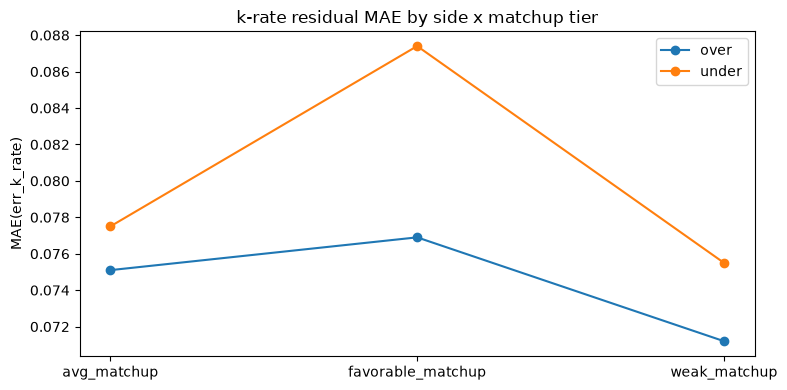

In [26]:
# Section 11d: stratified residual diagnostics.

if 'joined' in globals() and isinstance(joined, pl.DataFrame) and joined.height >= 20:
    diag = joined

    # Matchup tiers from opp_lineup_k_vs_hand.
    if 'opp_lineup_k_vs_hand' in diag.columns:
        diag = diag.with_columns(
            pl.col('opp_lineup_k_vs_hand')
            .qcut(3, labels=['weak_matchup', 'avg_matchup', 'favorable_matchup'], allow_duplicates=True)
            .alias('matchup_tier')
        )

    # Days-rest buckets.
    if 'days_rest' in diag.columns:
        diag = diag.with_columns(
            pl.when(pl.col('days_rest').is_null()).then(pl.lit('unknown'))
            .when(pl.col('days_rest') <= 4).then(pl.lit('short_0_4'))
            .when(pl.col('days_rest') <= 6).then(pl.lit('normal_5_6'))
            .when(pl.col('days_rest') <= 9).then(pl.lit('extended_7_9'))
            .otherwise(pl.lit('long_10_plus'))
            .alias('days_rest_bucket')
        )

    # Try to locate handedness-like columns if present.
    hand_col = next((c for c in ('throws_hand', 'pitcher_hand', 'pitch_hand', 'handedness', 'p_throws', 'throws') if c in diag.columns), None)

    def _slice_report(df: pl.DataFrame, by: str, min_n: int = 8) -> pl.DataFrame:
        out = (
            df.filter(pl.col(by).is_not_null())
            .group_by(by)
            .agg(
                pl.len().alias('n'),
                pl.col('err_k_rate').abs().mean().round(4).alias('mae_err_k_rate'),
                pl.col('err_k_rate').mean().round(4).alias('bias_err_k_rate'),
                pl.col('err_tbf').abs().mean().round(3).alias('mae_tbf'),
                pl.col('err_tbf').mean().round(3).alias('bias_tbf'),
                pl.col('err_full').abs().mean().round(3).alias('mae_full_k'),
                pl.col('result').eq('win').mean().round(3).alias('win_rate'),
                pl.col('clv_pp').mean().round(4).alias('mean_clv_pp'),
            )
            .filter(pl.col('n') >= min_n)
            .sort('mae_err_k_rate', descending=True)
        )
        return out

    print('--- k-rate / TBF residual by matchup tier ---')
    if 'matchup_tier' in diag.columns:
        print(_slice_report(diag, 'matchup_tier'))
    else:
        print('matchup tier unavailable (missing opp_lineup_k_vs_hand).')

    print('\n--- residual by days rest bucket ---')
    if 'days_rest_bucket' in diag.columns:
        print(_slice_report(diag, 'days_rest_bucket'))
    else:
        print('days_rest unavailable.')

    print('\n--- residual by pitcher handedness ---')
    if hand_col is not None:
        print(_slice_report(diag, hand_col))
    else:
        print('handedness column not found in current graded/projection artifacts.')

    # Side x matchup diagnostic to catch under-side PA bias concentration.
    if 'matchup_tier' in diag.columns:
        side_tier = (
            diag.group_by(['side', 'matchup_tier'])
            .agg(
                pl.len().alias('n'),
                pl.col('err_k_rate').abs().mean().round(4).alias('mae_err_k_rate'),
                pl.col('err_tbf').mean().round(3).alias('bias_tbf'),
                pl.col('err_full').abs().mean().round(3).alias('mae_full_k'),
            )
            .sort(['side', 'matchup_tier'])
        )
        print('\n--- side x matchup tier ---')
        print(side_tier)

        # Compact visual for where err_k_rate MAE spikes.
        _p = side_tier.to_pandas()
        if len(_p):
            import matplotlib.pyplot as _plt
            fig, ax = _plt.subplots(figsize=(8, 4))
            for side_name, grp in _p.groupby('side'):
                ax.plot(grp['matchup_tier'], grp['mae_err_k_rate'], marker='o', label=f'{side_name}')
            ax.set_ylabel('MAE(err_k_rate)')
            ax.set_title('k-rate residual MAE by side x matchup tier')
            ax.legend()
            _plt.tight_layout(); _plt.show()
else:
    print('Run Section 11c first (needs `joined` with residual columns).')

## 19. Appendix C — Chronological Recalibration Experiment (`k_rate_pred`)

This is a lightweight *post-model* check on the strikeout-rate component only.
We compare:

- raw `k_rate_pred`
- Platt-style mapping (logistic on `k_rate_pred`)
- isotonic regression

Protocol:
- chronological folds (train on earlier dates, validate on later dates)
- evaluate MAE on `actual_k_rate`
- require at least **15 distinct dates** before interpreting winner selection
- report whether mapping helps enough to justify follow-up in training code

Note: this is diagnostic, not a production deployment change.

In [27]:
# Section 11e: chronological isotonic vs Platt-style recalibration on k_rate_pred.

from datetime import datetime, timezone
import hashlib

DAILY_PATH = LEDGER_PATH.parent / 'k_error_decomposition_daily.parquet'

if 'joined' in globals() and isinstance(joined, pl.DataFrame) and joined.height >= 80:
    cal_src = (
        joined
        .with_columns(
            pl.col('game_date').str.strptime(pl.Date, '%Y-%m-%d', strict=False).alias('_d')
        )
        .filter(pl.col('_d').is_not_null())
        .sort('_d')
    )

    try:
        from sklearn.isotonic import IsotonicRegression
        from sklearn.linear_model import LogisticRegression

        dates = cal_src['_d'].unique().sort()
        d_list = dates.to_list()
        n_dates = len(d_list)

        CHRONO_MIN_DATES = 15
        if n_dates >= CHRONO_MIN_DATES:
            # 3 chronological folds with expanding train windows.
            cut_1 = int(n_dates * 0.55)
            cut_2 = int(n_dates * 0.70)
            cut_3 = int(n_dates * 0.82)
            fold_bounds = [
                (0, cut_1, cut_1, cut_2),
                (0, cut_2, cut_2, cut_3),
                (0, cut_3, cut_3, n_dates),
            ]

            fold_rows = []
            for i, (tr0, tr1, va0, va1) in enumerate(fold_bounds, start=1):
                tr_dates = d_list[tr0:tr1]
                va_dates = d_list[va0:va1]
                tr = cal_src.filter(pl.col('_d').is_in(tr_dates))
                va = cal_src.filter(pl.col('_d').is_in(va_dates))
                if tr.height < 30 or va.height < 15:
                    continue

                x_tr = tr['k_rate_pred'].to_numpy().reshape(-1, 1)
                y_tr = tr['actual_k_rate'].to_numpy()
                x_va = va['k_rate_pred'].to_numpy().reshape(-1, 1)
                y_va = va['actual_k_rate'].to_numpy()

                # Raw baseline.
                pred_raw = x_va.reshape(-1)

                # Platt-style (logistic on clipped target via binary pseudo-label around game k-rate).
                # For continuous-rate mapping, use logistic as a monotone squashing proxy.
                y_tr_bin = (y_tr >= y_tr.mean()).astype(int)
                lr = LogisticRegression(max_iter=200)
                lr.fit(x_tr, y_tr_bin)
                pred_platt = lr.predict_proba(x_va)[:, 1]
                # Re-scale back toward observed k-rate band on training data.
                lo, hi = float(y_tr.min()), float(y_tr.max())
                pred_platt = lo + pred_platt * max(1e-9, (hi - lo))

                # Isotonic on continuous target.
                iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
                iso.fit(x_tr.reshape(-1), y_tr)
                pred_iso = iso.predict(x_va.reshape(-1))

                def _mae(a, b):
                    import numpy as _np
                    return float(_np.mean(_np.abs(a - b)))

                fold_rows.extend([
                    {'fold': i, 'method': 'raw', 'n_valid': len(y_va), 'mae_k_rate': round(_mae(pred_raw, y_va), 5)},
                    {'fold': i, 'method': 'platt_style', 'n_valid': len(y_va), 'mae_k_rate': round(_mae(pred_platt, y_va), 5)},
                    {'fold': i, 'method': 'isotonic', 'n_valid': len(y_va), 'mae_k_rate': round(_mae(pred_iso, y_va), 5)},
                ])

            if fold_rows:
                fold_tbl = pl.DataFrame(fold_rows)
                print('--- chronological k_rate recalibration experiment ---')
                print(fold_tbl)
                summary = (
                    fold_tbl.group_by('method')
                    .agg(
                        pl.col('mae_k_rate').mean().round(5).alias('mean_mae_k_rate'),
                        pl.col('mae_k_rate').std().round(5).alias('std_mae_k_rate'),
                        pl.col('n_valid').sum().alias('total_valid_rows'),
                    )
                    .sort('mean_mae_k_rate')
                )
                print('\n--- method summary ---')
                print(summary)
            else:
                print('No valid chrono folds after minimum row checks.')
        else:
            print(f'Need >= {CHRONO_MIN_DATES} distinct game dates for stable chrono fold test (have {n_dates}).')

    except Exception as exc:
        print(f'Recalibration experiment skipped (sklearn unavailable or fit failed): {exc}')

    # Daily tracking snapshot for trend lines.
    led_bytes = LEDGER_PATH.read_bytes() if LEDGER_PATH.exists() else b''
    led_sha = hashlib.sha256(led_bytes).hexdigest() if led_bytes else None

    daily_row = pl.DataFrame([
        {
            'snapshot_utc': datetime.now(timezone.utc).isoformat(),
            'ledger_sha256': led_sha,
            'n_joined': int(cal_src.height),
            'mae_err_k_rate': float(cal_src.select(pl.col('err_k_rate').abs().mean()).item()),
            'bias_tbf_all': float(cal_src.select(pl.col('err_tbf').mean()).item()),
            'bias_tbf_under': float(
                cal_src.filter(pl.col('side') == 'under').select(pl.col('err_tbf').mean()).item()
            ) if cal_src.filter(pl.col('side') == 'under').height else None,
            'bias_tbf_over': float(
                cal_src.filter(pl.col('side') == 'over').select(pl.col('err_tbf').mean()).item()
            ) if cal_src.filter(pl.col('side') == 'over').height else None,
            'mae_full_k': float(cal_src.select(pl.col('err_full').abs().mean()).item()),
        }
    ])

    if DAILY_PATH.exists():
        hist = pl.read_parquet(DAILY_PATH)
        out = pl.concat([hist, daily_row], how='diagonal_relaxed')
        out = out.unique(subset=['ledger_sha256'], keep='last') if 'ledger_sha256' in out.columns else out
    else:
        out = daily_row
    out.write_parquet(DAILY_PATH)
    print(f'\nwrote {DAILY_PATH.name} ({out.height} snapshots)')

else:
    print('Run Section 11c first; need >=80 rows with residual columns for this experiment.')

--- chronological k_rate recalibration experiment ---
shape: (9, 4)
┌──────┬─────────────┬─────────┬────────────┐
│ fold ┆ method      ┆ n_valid ┆ mae_k_rate │
│ ---  ┆ ---         ┆ ---     ┆ ---        │
│ i64  ┆ str         ┆ i64     ┆ f64        │
╞══════╪═════════════╪═════════╪════════════╡
│ 1    ┆ raw         ┆ 154     ┆ 0.07407    │
│ 1    ┆ platt_style ┆ 154     ┆ 0.09896    │
│ 1    ┆ isotonic    ┆ 154     ┆ 0.07342    │
│ 2    ┆ raw         ┆ 113     ┆ 0.07089    │
│ 2    ┆ platt_style ┆ 113     ┆ 0.12943    │
│ 2    ┆ isotonic    ┆ 113     ┆ 0.07496    │
│ 3    ┆ raw         ┆ 160     ┆ 0.07842    │
│ 3    ┆ platt_style ┆ 160     ┆ 0.1133     │
│ 3    ┆ isotonic    ┆ 160     ┆ 0.08104    │
└──────┴─────────────┴─────────┴────────────┘

--- method summary ---
shape: (3, 4)
┌─────────────┬─────────────────┬────────────────┬──────────────────┐
│ method      ┆ mean_mae_k_rate ┆ std_mae_k_rate ┆ total_valid_rows │
│ ---         ┆ ---             ┆ ---            ┆ ---          

## 20. Appendix D — Model Health Scorecard (10-second daily scan)

This section compresses the key diagnostics into PASS/WARN flags so daily review
is fast and repeatable.

Current checks:
- enough decomposition sample (`n_joined`)
- `mae_err_k_rate`
- under-side `bias_tbf`
- worst matchup-tier `mae_err_k_rate`
- long-rest (`10+`) `bias_tbf` stability

A daily snapshot is appended to:
`artifacts/odds_log/model_health_scorecard_daily.parquet`

In [28]:
# Section 11f: model health scorecard.

SCORECARD_PATH = LEDGER_PATH.parent / 'model_health_scorecard_daily.parquet'

if 'joined' in globals() and isinstance(joined, pl.DataFrame) and joined.height >= 20:
    sc = joined

    # Derived slices reused by scorecard checks.
    if 'opp_lineup_k_vs_hand' in sc.columns:
        sc = sc.with_columns(
            pl.col('opp_lineup_k_vs_hand')
            .qcut(3, labels=['weak_matchup', 'avg_matchup', 'favorable_matchup'], allow_duplicates=True)
            .alias('matchup_tier')
        )

    if 'days_rest' in sc.columns:
        sc = sc.with_columns(
            pl.when(pl.col('days_rest').is_null()).then(pl.lit('unknown'))
            .when(pl.col('days_rest') <= 4).then(pl.lit('short_0_4'))
            .when(pl.col('days_rest') <= 6).then(pl.lit('normal_5_6'))
            .when(pl.col('days_rest') <= 9).then(pl.lit('extended_7_9'))
            .otherwise(pl.lit('long_10_plus'))
            .alias('days_rest_bucket')
        )

    # Tunable thresholds (start conservative; tighten as sample grows).
    MIN_JOINED = 100
    MAE_KRATE_WARN = 0.075
    ABS_UNDER_TBF_BIAS_WARN = 1.50
    WORST_TIER_MAE_WARN = 0.078
    ABS_LONG_REST_BIAS_WARN = 3.00

    n_joined = int(sc.height)
    mae_err_k_rate = float(sc.select(pl.col('err_k_rate').abs().mean()).item())

    under_df = sc.filter(pl.col('side') == 'under')
    under_bias_tbf = float(under_df.select(pl.col('err_tbf').mean()).item()) if under_df.height else float('nan')

    worst_tier_mae = float('nan')
    if 'matchup_tier' in sc.columns:
        tier_tbl = (
            sc.group_by('matchup_tier')
            .agg(pl.col('err_k_rate').abs().mean().alias('mae_err_k_rate'), pl.len().alias('n'))
            .filter(pl.col('n') >= 8)
        )
        if tier_tbl.height:
            worst_tier_mae = float(tier_tbl['mae_err_k_rate'].max())

    long_rest_bias = float('nan')
    if 'days_rest_bucket' in sc.columns:
        lr = sc.filter(pl.col('days_rest_bucket') == 'long_10_plus')
        if lr.height >= 8:
            long_rest_bias = float(lr.select(pl.col('err_tbf').mean()).item())

    checks = [
        {
            'check': 'sample_size_n_joined',
            'value': n_joined,
            'threshold': f'>= {MIN_JOINED}',
            'status': 'PASS' if n_joined >= MIN_JOINED else 'WARN',
        },
        {
            'check': 'mae_err_k_rate',
            'value': round(mae_err_k_rate, 4),
            'threshold': f'<= {MAE_KRATE_WARN:.3f}',
            'status': 'PASS' if mae_err_k_rate <= MAE_KRATE_WARN else 'WARN',
        },
        {
            'check': 'under_side_bias_tbf',
            'value': round(under_bias_tbf, 3) if under_bias_tbf == under_bias_tbf else None,
            'threshold': f'abs <= {ABS_UNDER_TBF_BIAS_WARN:.2f}',
            'status': 'PASS' if (under_bias_tbf == under_bias_tbf and abs(under_bias_tbf) <= ABS_UNDER_TBF_BIAS_WARN) else 'WARN',
        },
        {
            'check': 'worst_matchup_tier_mae_err_k_rate',
            'value': round(worst_tier_mae, 4) if worst_tier_mae == worst_tier_mae else None,
            'threshold': f'<= {WORST_TIER_MAE_WARN:.3f}',
            'status': 'PASS' if (worst_tier_mae == worst_tier_mae and worst_tier_mae <= WORST_TIER_MAE_WARN) else 'WARN',
        },
        {
            'check': 'long_rest_bias_tbf',
            'value': round(long_rest_bias, 3) if long_rest_bias == long_rest_bias else None,
            'threshold': f'abs <= {ABS_LONG_REST_BIAS_WARN:.2f} (n>=8)',
            'status': 'PASS' if (long_rest_bias == long_rest_bias and abs(long_rest_bias) <= ABS_LONG_REST_BIAS_WARN) else 'WARN',
        },
    ]

    scorecard = pl.DataFrame(checks)
    print('--- model health scorecard ---')
    print(scorecard)

    n_warn = int(scorecard.filter(pl.col('status') == 'WARN').height)
    print(f"\nOverall: {'PASS' if n_warn == 0 else 'WARN'} ({n_warn} warning checks)")

    # Persist one daily snapshot row (key metrics + warn count).
    import hashlib
    from datetime import datetime, timezone

    led_sha = hashlib.sha256(LEDGER_PATH.read_bytes()).hexdigest() if LEDGER_PATH.exists() else None
    snap = pl.DataFrame([
        {
            'snapshot_utc': datetime.now(timezone.utc).isoformat(),
            'ledger_sha256': led_sha,
            'n_joined': n_joined,
            'mae_err_k_rate': mae_err_k_rate,
            'under_bias_tbf': under_bias_tbf if under_bias_tbf == under_bias_tbf else None,
            'worst_tier_mae_err_k_rate': worst_tier_mae if worst_tier_mae == worst_tier_mae else None,
            'long_rest_bias_tbf': long_rest_bias if long_rest_bias == long_rest_bias else None,
            'n_warn': n_warn,
        }
    ])

    if SCORECARD_PATH.exists():
        hist = pl.read_parquet(SCORECARD_PATH)
        out = pl.concat([hist, snap], how='diagonal_relaxed')
        out = out.unique(subset=['ledger_sha256'], keep='last') if 'ledger_sha256' in out.columns else out
    else:
        out = snap
    out.write_parquet(SCORECARD_PATH)
    print(f"wrote {SCORECARD_PATH.name} ({out.height} snapshots)")
else:
    print('Run Section 11c first (needs `joined` with residual columns).')

--- model health scorecard ---
shape: (5, 4)
┌─────────────────────────────────┬────────┬────────────────────┬────────┐
│ check                           ┆ value  ┆ threshold          ┆ status │
│ ---                             ┆ ---    ┆ ---                ┆ ---    │
│ str                             ┆ f64    ┆ str                ┆ str    │
╞═════════════════════════════════╪════════╪════════════════════╪════════╡
│ sample_size_n_joined            ┆ 743.0  ┆ >= 100             ┆ PASS   │
│ mae_err_k_rate                  ┆ 0.0776 ┆ <= 0.075           ┆ WARN   │
│ under_side_bias_tbf             ┆ -1.081 ┆ abs <= 1.50        ┆ PASS   │
│ worst_matchup_tier_mae_err_k_r… ┆ 0.0827 ┆ <= 0.078           ┆ WARN   │
│ long_rest_bias_tbf              ┆ -8.582 ┆ abs <= 3.00 (n>=8) ┆ WARN   │
└─────────────────────────────────┴────────┴────────────────────┴────────┘

Overall: WARN (3 warning checks)
wrote model_health_scorecard_daily.parquet (10 snapshots)
